# 🧘 MindGuide AI — A Hybrid Meditation Recommendation System

**A flagship, end-to-end machine-learning project** that recommends personalized meditation
sessions using content-based retrieval, collaborative filtering, learning-to-rank, semantic
search, and explainable AI.

This single notebook runs top-to-bottom in **Google Colab** with no manual data collection,
no CSV uploads, and no file editing. Every dataset is obtained or generated programmatically,
every folder is created automatically, and every artifact is saved automatically.

---

## What this notebook builds

| Stage | Component |
|------|-----------|
| **ETL** | Automated acquisition of real meditation-technique text (Wikipedia public API) + procedural session catalog |
| **Preprocessing** | HTML/emoji/punctuation cleaning, dedup, language detection, normalization |
| **Feature engineering** | Lexicon-based intent scores, difficulty estimation, keyword features, sentence embeddings |
| **Model 1** | Content-based retrieval (embedding cosine similarity + nearest-neighbor / FAISS) |
| **Model 2** | Collaborative filtering (implicit ALS → matrix-factorization fallback, optional Neural CF) |
| **Model 3** | Popularity baseline |
| **Model 4** | Learning-to-rank (LightGBM Ranker → XGBoost fallback) |
| **Cold start** | Onboarding questionnaire → semantic + category + popularity blend |
| **Semantic search** | Natural-language query → embedding retrieval with duration/keyword parsing |
| **Explainability** | SHAP on the ranker (summary + feature importance + per-item explanations) |
| **Evaluation** | Precision/Recall@K, MAP, MRR, NDCG, HitRate, Coverage, Diversity, Novelty, Personalization |
| **Visualization** | Distributions, UMAP projection, clustering, heatmaps, SHAP, score distributions |
| **Dashboard** | Auto-generated Streamlit app |
| **Report** | Auto-generated PDF summary |

---

### ⚠️ An honest note on data sources (please read)

The prompt asks for fully-automated ingestion of YouTube transcripts and Reddit discussions.
In practice those pipelines are **not reliably automatable** on a fresh Colab machine:

* **Reddit** removed anonymous bulk access; the modern API requires authenticated OAuth
  credentials, and unauthenticated scraping violates their terms.
* **YouTube** transcript scraping needs specific video IDs and is frequently rate-limited or
  IP-blocked on Colab; hard-coding IDs I cannot verify would mean *fabricating data*, which the
  prompt explicitly forbids.

Following the prompt's own guidance — *"replace it with the strongest feasible alternative using
only public data, clearly document the substitution, and keep the pipeline fully automated"* —
this notebook uses a genuinely reliable, no-auth public source (**Wikipedia's Action API**) to
pull **real** meditation-technique text, and then **procedurally generates** a labeled synthetic
session catalog grounded in that real text. Synthetic users and interactions are explicitly
requested by the prompt and are generated reproducibly. Every substitution is labeled in-line.
The pipeline stays 100% automated and degrades gracefully if any network call fails.

## 1 · Environment Setup

Installs are grouped and wrapped in `try/except` so a single failed wheel never breaks the run.
Optional accelerators (`implicit`, `faiss-cpu`, `umap-learn`, `pyngrok`) degrade to pure-Python
or scikit-learn fallbacks if they fail to install. We use `subprocess` (not `!pip`) so every cell
is valid Python and the notebook stays lint-clean.

In [1]:
# --- Dependency installation (resilient, grouped) -----------------------------
import sys, subprocess, importlib, time

def _pip_install(pkgs, label):
    """Install a group of packages; never raise. Returns True on success."""
    t0 = time.time()
    try:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", *pkgs],
            check=True,
        )
        print(f"  ✓ {label:<22} ({time.time()-t0:4.1f}s)")
        return True
    except Exception as e:  # noqa: BLE001
        print(f"  ✗ {label:<22} failed: {type(e).__name__} — continuing with fallback")
        return False

IN_COLAB = "google.colab" in sys.modules
print(f"Running in Colab: {IN_COLAB}")
print("Installing dependencies (this is the slowest cell; grab a cup of tea)…\n")

# Core scientific stack — almost always present in Colab, installed to pin sanity.
_pip_install(["numpy", "pandas", "scikit-learn", "scipy", "tqdm", "joblib"], "core")
_pip_install(["matplotlib", "plotly"], "plotting")
# NLP / embeddings
_pip_install(["sentence-transformers"], "sentence-transformers")
# Gradient-boosted rankers
_pip_install(["lightgbm", "xgboost"], "rankers")
# Explainability
_pip_install(["shap"], "shap")
# Text utilities
_pip_install(["emoji", "langdetect", "beautifulsoup4", "requests"], "text-utils")
# PDF report
_pip_install(["reportlab"], "reportlab")
# --- Optional accelerators (fallbacks exist if these fail) ---
OPT = {}
OPT["implicit"] = _pip_install(["implicit"], "implicit (optional)")
OPT["faiss"]    = _pip_install(["faiss-cpu"], "faiss-cpu (optional)")
OPT["umap"]     = _pip_install(["umap-learn"], "umap-learn (optional)")
OPT["pyngrok"]  = _pip_install(["pyngrok"], "pyngrok (optional)")

print("\nDependency installation complete.")

Running in Colab: True
Installing dependencies (this is the slowest cell; grab a cup of tea)…

  ✓ core                   ( 7.1s)
  ✓ plotting               ( 7.8s)
  ✓ sentence-transformers  ( 6.4s)
  ✓ rankers                ( 6.9s)
  ✓ shap                   ( 5.5s)
  ✓ text-utils             (12.2s)
  ✓ reportlab              ( 5.3s)
  ✓ implicit (optional)    ( 3.0s)
  ✓ faiss-cpu (optional)   ( 4.0s)
  ✓ umap-learn (optional)  ( 2.7s)
  ✓ pyngrok (optional)     ( 3.6s)

Dependency installation complete.


## 2 · Imports, Configuration, Reproducibility, Logging & Project Structure

A single `CFG` object centralizes every tunable. `set_global_seeds()` seeds Python, NumPy and
Torch (if present) so results are reproducible. A logger writes to both the console and
`mindguide_ai/logs/run.log`. The full project folder tree is created automatically.

In [2]:
# --- Imports ------------------------------------------------------------------
import os, sys, re, json, math, random, logging, warnings, pickle, hashlib, time
from pathlib import Path
from dataclasses import dataclass, field, asdict
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 140)

# Torch is optional (used for Neural CF and to seed CUDA); guard the import.
try:
    import torch
    TORCH_AVAILABLE = True
except Exception:  # noqa: BLE001
    TORCH_AVAILABLE = False


# --- Central configuration ----------------------------------------------------
@dataclass
class Config:
    seed: int = 42
    # data sizes
    n_users: int = 4000
    sessions_per_technique: int = 26      # catalog breadth multiplier
    # embeddings
    embed_model: str = "sentence-transformers/all-MiniLM-L6-v2"
    embed_batch: int = 64
    # interactions
    min_interactions: int = 8
    max_interactions: int = 45
    test_frac: float = 0.2                # per-user hold-out fraction
    # evaluation
    k_values: tuple = (5, 10)
    eval_user_sample: int = 1200          # cap eval users for speed
    # ranking
    lgbm_estimators: int = 300
    # misc
    root: str = "mindguide_ai"

    @property
    def durations(self):
        return [3, 5, 8, 10, 12, 15, 20, 25, 30, 45]

CFG = Config()


# --- Reproducibility ----------------------------------------------------------
def set_global_seeds(seed: int = CFG.seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    return np.random.default_rng(seed)

RNG = set_global_seeds(CFG.seed)   # a NumPy Generator used throughout


# --- Project folder tree ------------------------------------------------------
ROOT = Path(CFG.root)
PATHS = {
    "root":       ROOT,
    "raw":        ROOT / "data" / "raw",
    "processed":  ROOT / "data" / "processed",
    "embeddings": ROOT / "data" / "embeddings",
    "models":     ROOT / "models",
    "outputs":    ROOT / "outputs",
    "figures":    ROOT / "figures",
    "dashboard":  ROOT / "dashboard",
    "cache":      ROOT / "cache",
    "logs":       ROOT / "logs",
    "shap":       ROOT / "outputs" / "SHAP_Analysis",
}
for p in PATHS.values():
    p.mkdir(parents=True, exist_ok=True)


# --- Logging ------------------------------------------------------------------
logger = logging.getLogger("mindguide")
logger.setLevel(logging.INFO)
logger.handlers.clear()
_fmt = logging.Formatter("%(asctime)s | %(levelname)-7s | %(message)s", "%H:%M:%S")
_ch = logging.StreamHandler(sys.stdout); _ch.setFormatter(_fmt); logger.addHandler(_ch)
_fh = logging.FileHandler(PATHS["logs"] / "run.log", mode="w"); _fh.setFormatter(_fmt)
logger.addHandler(_fh)

# Device banner
if TORCH_AVAILABLE and torch.cuda.is_available():
    logger.info("Torch CUDA available: %s", torch.cuda.get_device_name(0))
else:
    logger.info("Running on CPU (Torch available: %s)", TORCH_AVAILABLE)

logger.info("Project tree created under ./%s", CFG.root)
logger.info("Config: %s", json.dumps({k: v for k, v in asdict(CFG).items()}))


# --- Small utilities ----------------------------------------------------------
class Timer:
    """Context manager that logs elapsed wall-clock time for a stage."""
    def __init__(self, name): self.name = name
    def __enter__(self): self.t0 = time.time(); logger.info("▶ %s …", self.name); return self
    def __exit__(self, *exc):
        logger.info("■ %s done in %.1fs", self.name, time.time() - self.t0)

def cache_path(name: str) -> Path:
    return PATHS["cache"] / name

def save_pickle(obj, path):
    with open(path, "wb") as fh:
        pickle.dump(obj, fh, protocol=pickle.HIGHEST_PROTOCOL)

def load_pickle(path):
    with open(path, "rb") as fh:
        return pickle.load(fh)

print("Setup complete. Everything below runs top-to-bottom.")

18:35:00 | INFO    | Torch CUDA available: Tesla T4


INFO:mindguide:Torch CUDA available: Tesla T4


18:35:00 | INFO    | Project tree created under ./mindguide_ai


INFO:mindguide:Project tree created under ./mindguide_ai


18:35:00 | INFO    | Config: {"seed": 42, "n_users": 4000, "sessions_per_technique": 26, "embed_model": "sentence-transformers/all-MiniLM-L6-v2", "embed_batch": 64, "min_interactions": 8, "max_interactions": 45, "test_frac": 0.2, "k_values": [5, 10], "eval_user_sample": 1200, "lgbm_estimators": 300, "root": "mindguide_ai"}


INFO:mindguide:Config: {"seed": 42, "n_users": 4000, "sessions_per_technique": 26, "embed_model": "sentence-transformers/all-MiniLM-L6-v2", "embed_batch": 64, "min_interactions": 8, "max_interactions": 45, "test_frac": 0.2, "k_values": [5, 10], "eval_user_sample": 1200, "lgbm_estimators": 300, "root": "mindguide_ai"}


Setup complete. Everything below runs top-to-bottom.


## 3 · Automated Data Acquisition (ETL)

**Real public source:** Wikipedia's Action API (`en.wikipedia.org/w/api.php`) — no auth, no
paywall, polite `User-Agent`, cached to disk. We pull plain-text extracts for a curated set of
**real** meditation-technique articles. If the network is unavailable, a factual built-in seed
dictionary keeps the pipeline running.

**Procedural catalog:** each real technique seeds a family of meditation *sessions* (varying
duration, category, instructor, breathing style). Descriptions and transcripts are synthesized
from the real technique text plus guidance templates, so the resulting corpus has genuine
semantic structure for the embedding models to exploit. The catalog is clearly synthetic and
fully reproducible.

In [3]:
import requests

# Real Wikipedia articles about meditation techniques (all exist as of writing).
WIKI_TITLES = [
    "Mindfulness", "Meditation", "Vipassanā", "Anapanasati", "Mettā",
    "Yoga nidra", "Transcendental Meditation", "Guided meditation",
    "Loving-kindness meditation", "Pranayama", "Zen", "Body scan meditation",
    "Progressive muscle relaxation", "Breathwork", "Mantra", "Chakra",
]

WIKI_API = "https://en.wikipedia.org/w/api.php"
HEADERS = {"User-Agent": "MindGuideAI-Portfolio/1.0 (educational; contact: example@example.com)"}

# Factual fallback blurbs (used only if the network call fails) — no fabricated URLs.
FALLBACK_TECHNIQUES = {
    "Mindfulness": "Mindfulness is the practice of purposely bringing one's attention to "
        "experiences occurring in the present moment without judgment. It cultivates awareness "
        "of breath, body sensations, thoughts and emotions as they arise and pass.",
    "Anapanasati": "Anapanasati means mindfulness of breathing. The practitioner rests attention "
        "on the natural sensation of the breath at the nostrils or abdomen, returning gently "
        "whenever the mind wanders.",
    "Mettā": "Metta, or loving-kindness meditation, develops benevolence toward oneself and "
        "others by silently repeating well-wishing phrases and radiating warmth outward.",
    "Body scan meditation": "A body scan moves attention slowly through the body from head to "
        "toe, noticing sensations, releasing tension and grounding awareness in physical feeling.",
    "Pranayama": "Pranayama is the yogic regulation of breath through techniques that lengthen, "
        "retain and control inhalation and exhalation to steady the mind and energy.",
    "Progressive muscle relaxation": "Progressive muscle relaxation systematically tenses and "
        "releases muscle groups to reduce physical tension and promote deep relaxation and sleep.",
    "Yoga nidra": "Yoga nidra is a guided practice of psychic sleep that leads the body into deep "
        "relaxation while the mind stays lightly aware, restoring rest and calm.",
    "Transcendental Meditation": "Transcendental Meditation uses the silent repetition of a mantra "
        "to settle the mind into a state of restful alertness beyond ordinary thinking.",
}

def fetch_wikipedia_extract(title, timeout=15):
    """Fetch a plain-text extract for one article; return None on any failure."""
    params = {
        "action": "query", "prop": "extracts", "explaintext": 1,
        "exsectionformat": "plain", "redirects": 1, "format": "json", "titles": title,
    }
    try:
        r = requests.get(WIKI_API, params=params, headers=HEADERS, timeout=timeout)
        r.raise_for_status()
        pages = r.json()["query"]["pages"]
        page = next(iter(pages.values()))
        text = page.get("extract", "")
        return text if text and len(text) > 200 else None
    except Exception as e:  # noqa: BLE001
        logger.warning("Wikipedia fetch failed for %r: %s", title, e)
        return None

def acquire_techniques():
    """Return {title: raw_text}. Cached; falls back gracefully."""
    cache = cache_path("wiki_techniques.json")
    if cache.exists():
        logger.info("Loading cached Wikipedia extracts.")
        return json.loads(cache.read_text())

    out = {}
    with Timer("Downloading Wikipedia meditation articles"):
        for t in tqdm(WIKI_TITLES, desc="wiki"):
            txt = fetch_wikipedia_extract(t)
            if txt:
                out[t] = txt
            time.sleep(0.4)  # be polite
    if len(out) < 3:  # network largely failed -> use factual fallback
        logger.warning("Few/no articles fetched; using built-in factual fallback text.")
        out = dict(FALLBACK_TECHNIQUES)
    cache.write_text(json.dumps(out))
    logger.info("Acquired %d technique articles.", len(out))
    return out

TECH_RAW = acquire_techniques()
print(f"Techniques acquired: {list(TECH_RAW.keys())}")

18:35:00 | INFO    | ▶ Downloading Wikipedia meditation articles …


INFO:mindguide:▶ Downloading Wikipedia meditation articles …


wiki:   0%|          | 0/16 [00:00<?, ?it/s]

18:35:10 | INFO    | ■ Downloading Wikipedia meditation articles done in 10.1s


INFO:mindguide:■ Downloading Wikipedia meditation articles done in 10.1s


18:35:10 | INFO    | Acquired 15 technique articles.


INFO:mindguide:Acquired 15 technique articles.


Techniques acquired: ['Mindfulness', 'Meditation', 'Vipassanā', 'Anapanasati', 'Mettā', 'Yoga nidra', 'Transcendental Meditation', 'Guided meditation', 'Loving-kindness meditation', 'Pranayama', 'Zen', 'Progressive muscle relaxation', 'Breathwork', 'Mantra', 'Chakra']


In [4]:
# --- Split technique text into clean sentences for later synthesis ------------
def split_sentences(text, min_len=25, max_len=320):
    text = re.sub(r"==+.*?==+", " ", text)          # drop section headers
    text = re.sub(r"\s+", " ", text).strip()
    parts = re.split(r"(?<=[.!?])\s+", text)
    good = [p.strip() for p in parts if min_len <= len(p.strip()) <= max_len]
    # discard sentences that are mostly citations / parentheses noise
    good = [p for p in good if p.count("(") <= 2 and not p.startswith("See also")]
    return good

TECH_SENTENCES = {t: split_sentences(txt) for t, txt in TECH_RAW.items()}
TECH_SENTENCES = {t: s for t, s in TECH_SENTENCES.items() if len(s) >= 2}
# Guarantee at least the fallback techniques are present with content.
for t, txt in FALLBACK_TECHNIQUES.items():
    if t not in TECH_SENTENCES:
        TECH_SENTENCES[t] = split_sentences(txt, min_len=15)
logger.info("Usable techniques with >=2 sentences: %d", len(TECH_SENTENCES))
for t, s in list(TECH_SENTENCES.items())[:3]:
    print(f"  {t}: {len(s)} sentences | e.g. “{s[0][:90]}…”")

18:35:11 | INFO    | Usable techniques with >=2 sentences: 15


INFO:mindguide:Usable techniques with >=2 sentences: 15


  Mindfulness: 322 sentences | e.g. “The term mindfulness derives from the Pali word sati, a significant element of Buddhist tr…”
  Meditation: 292 sentences | e.g. “Meditation techniques are broadly classified into focused (or concentrative) and open moni…”
  Vipassanā: 221 sentences | e.g. “While jhāna has a central role in the Buddhist path, vipassanā is rarely mentioned separat…”


In [5]:
# --- Procedural session catalog ----------------------------------------------
# Vocabularies (instructors are fictional but plausible; clearly synthetic).
INSTRUCTORS = ["Maya Chen", "Arjun Rao", "Sofia Marino", "Liam O'Brien", "Aisha Bello",
               "Noah Fischer", "Priya Nair", "Diego Alvarez", "Hana Kim", "Elena Petrova",
               "Marcus Webb", "Yuki Tanaka"]
CATEGORIES = ["Sleep", "Anxiety", "Focus", "Mindfulness", "Gratitude", "Stress Relief",
              "Breathing", "Body Scan", "Self-Compassion", "Beginner Basics"]
BREATHING_STYLES = ["Natural breath", "Box breathing", "4-7-8 breathing",
                    "Diaphragmatic", "Alternate nostril", "Ocean breath", "Coherent breathing"]
TIME_TAGS = ["Morning", "Midday", "After Work", "Evening", "Before Sleep", "Anytime"]

# Technique -> category affinity (higher = more likely). Others get a small base weight.
TECH_CATEGORY_AFFINITY = {
    "Yoga nidra": {"Sleep": 5, "Body Scan": 3, "Stress Relief": 2},
    "Progressive muscle relaxation": {"Sleep": 4, "Body Scan": 4, "Stress Relief": 3},
    "Body scan meditation": {"Body Scan": 5, "Mindfulness": 3, "Sleep": 2},
    "Anapanasati": {"Breathing": 5, "Focus": 3, "Mindfulness": 3},
    "Pranayama": {"Breathing": 5, "Anxiety": 3, "Stress Relief": 2},
    "Breathwork": {"Breathing": 5, "Stress Relief": 3, "Anxiety": 2},
    "Mettā": {"Self-Compassion": 5, "Gratitude": 4},
    "Loving-kindness meditation": {"Self-Compassion": 5, "Gratitude": 4},
    "Mindfulness": {"Mindfulness": 5, "Anxiety": 3, "Focus": 2, "Stress Relief": 2},
    "Vipassanā": {"Mindfulness": 5, "Focus": 3},
    "Zen": {"Focus": 4, "Mindfulness": 4},
    "Transcendental Meditation": {"Focus": 3, "Stress Relief": 3, "Anxiety": 2},
    "Mantra": {"Focus": 4, "Mindfulness": 2},
    "Guided meditation": {"Beginner Basics": 5, "Mindfulness": 2, "Sleep": 2},
    "Meditation": {"Beginner Basics": 4, "Mindfulness": 3},
    "Chakra": {"Self-Compassion": 2, "Mindfulness": 2, "Gratitude": 2},
}

TITLE_TEMPLATES = [
    "{cat} {tech}", "{dur}-Minute {cat} Practice", "{tech} for {cat}",
    "{time} {cat} Meditation", "Guided {tech}", "Deep {cat} with {tech}",
    "{cat} Reset", "A {dur}-Minute {tech} Journey",
]

INTRO_LINES = [
    "Find a comfortable position and allow your body to settle.",
    "Gently close your eyes and take a slow, easy breath.",
    "Let this be a moment that belongs entirely to you.",
    "Soften your shoulders and release the weight of the day.",
]
GUIDANCE_LINES = [
    "With each exhale, let a little more tension dissolve.",
    "If the mind wanders, that is completely natural — simply return.",
    "Notice, without judgment, whatever arises in this moment.",
    "There is nowhere to be and nothing to fix right now.",
    "Rest your attention lightly, like a feather on the breath.",
]
CLOSING_LINES = [
    "When you are ready, gently widen your awareness and open your eyes.",
    "Carry this calm with you into whatever comes next.",
    "Take a moment to appreciate the stillness you created.",
]

def _weighted_category(technique):
    weights = np.ones(len(CATEGORIES)) * 0.5
    aff = TECH_CATEGORY_AFFINITY.get(technique, {})
    for c, w in aff.items():
        weights[CATEGORIES.index(c)] += w
    weights = weights / weights.sum()
    return CATEGORIES[RNG.choice(len(CATEGORIES), p=weights)]

def _difficulty_from(duration, technique):
    base = 0.0
    if duration >= 25: base += 1
    if duration <= 8:  base -= 0.5
    if technique in ("Vipassanā", "Zen", "Pranayama", "Chakra", "Transcendental Meditation"):
        base += 1
    if technique in ("Guided meditation", "Meditation", "Progressive muscle relaxation"):
        base -= 0.5
    roll = base + RNG.normal(0, 0.6)
    if roll < -0.2: return "Beginner"
    if roll < 1.0:  return "Intermediate"
    return "Advanced"

def build_catalog():
    rows = []
    sid = 0
    techniques = list(TECH_SENTENCES.keys())
    with Timer("Building procedural session catalog"):
        for tech in techniques:
            sents = TECH_SENTENCES[tech]
            for _ in range(CFG.sessions_per_technique):
                cat = _weighted_category(tech)
                dur = int(RNG.choice(CFG.durations))
                instr = INSTRUCTORS[RNG.integers(len(INSTRUCTORS))]
                style = BREATHING_STYLES[RNG.integers(len(BREATHING_STYLES))]
                ttag = TIME_TAGS[RNG.integers(len(TIME_TAGS))]
                diff = _difficulty_from(dur, tech)

                title = RNG.choice(TITLE_TEMPLATES).format(
                    cat=cat, tech=tech.split(" (")[0], dur=dur, time=ttag)

                # Description: 1 real technique sentence + templated guidance.
                seed_sent = sents[RNG.integers(len(sents))]
                desc = (f"{title}. {seed_sent} This {dur}-minute {cat.lower()} session, guided by "
                        f"{instr}, uses {style.lower()} to help you {cat.lower()} with ease.")

                # Transcript: assembled to a realistic length from real + guidance sentences.
                n_body = int(np.clip(dur * 2 + RNG.integers(-2, 4), 6, 60))
                body = []
                body.append(RNG.choice(INTRO_LINES))
                for _i in range(n_body):
                    if RNG.random() < 0.45 and sents:
                        body.append(sents[RNG.integers(len(sents))])
                    else:
                        body.append(RNG.choice(GUIDANCE_LINES))
                body.append(RNG.choice(CLOSING_LINES))
                transcript = " ".join(body)

                rows.append(dict(
                    session_id=sid, title=title, description=desc, transcript=transcript,
                    instructor=instr, duration_min=dur, category=cat, technique=tech,
                    breathing_style=style, time_tag=ttag, difficulty=diff,
                ))
                sid += 1
    df = pd.DataFrame(rows)
    return df

sessions_raw = build_catalog()
sessions_raw.to_csv(PATHS["raw"] / "sessions_raw.csv", index=False)
logger.info("Catalog built: %d sessions across %d techniques, %d categories.",
            len(sessions_raw), sessions_raw.technique.nunique(), sessions_raw.category.nunique())
sessions_raw[["title", "category", "technique", "duration_min", "instructor", "difficulty"]].head(8)

18:35:11 | INFO    | ▶ Building procedural session catalog …


INFO:mindguide:▶ Building procedural session catalog …


18:35:12 | INFO    | ■ Building procedural session catalog done in 0.6s


INFO:mindguide:■ Building procedural session catalog done in 0.6s


18:35:12 | INFO    | Catalog built: 390 sessions across 15 techniques, 10 categories.


INFO:mindguide:Catalog built: 390 sessions across 15 techniques, 10 categories.


,title,category,technique,duration_min,instructor,difficulty
0,20-Minute Stress Relief Practice,Stress Relief,Mindfulness,20,Noah Fischer,Intermediate
1,A 10-Minute Mindfulness Journey,Anxiety,Mindfulness,10,Noah Fischer,Intermediate
2,Focus Reset,Focus,Mindfulness,20,Elena Petrova,Intermediate
3,A 8-Minute Mindfulness Journey,Focus,Mindfulness,8,Yuki Tanaka,Beginner
4,Anxiety Mindfulness,Anxiety,Mindfulness,45,Maya Chen,Advanced
5,Guided Mindfulness,Stress Relief,Mindfulness,20,Hana Kim,Intermediate
6,Mindfulness for Focus,Focus,Mindfulness,25,Elena Petrova,Intermediate
7,Anytime Mindfulness Meditation,Mindfulness,Mindfulness,3,Maya Chen,Beginner


## 4 · Preprocessing & Cleaning

HTML stripping, emoji handling, punctuation/whitespace normalization, deduplication, language
detection and missing-value handling. We keep a **display** version of the text (lightly cleaned,
readable) and a **token** version (lowercased, stopword-free) used only for keyword features —
embeddings are computed on the readable text, where stopwords carry meaning.

In [6]:
try:
    from bs4 import BeautifulSoup
    _HAS_BS4 = True
except Exception:
    _HAS_BS4 = False
try:
    import emoji as _emoji
    _HAS_EMOJI = True
except Exception:
    _HAS_EMOJI = False
try:
    from langdetect import detect as _lang_detect
    _HAS_LANG = True
except Exception:
    _HAS_LANG = False

_EMOJI_RE = re.compile(
    "[" "\U0001F300-\U0001FAFF" "\U00002700-\U000027BF"
    "\U0001F000-\U0001F0FF" "\U00002600-\U000026FF" "\U0001F900-\U0001F9FF" "]+",
    flags=re.UNICODE,
)

STOPWORDS = set("""a an the and or but if then else of to in on at by for with without into
from up down over under again further once here there all any both each few more most other some
such no nor not only own same so than too very can will just is are was were be been being do does
did have has had having i you he she it we they them your his her its our their this that these those
as about above below between out off am me my mine ours yours""".split())

def strip_html(text):
    if not isinstance(text, str) or "<" not in text:
        return text if isinstance(text, str) else ""
    if _HAS_BS4:
        return BeautifulSoup(text, "html.parser").get_text(" ")
    return re.sub(r"<[^>]+>", " ", text)

def handle_emoji(text):
    if not isinstance(text, str):
        return ""
    if _HAS_EMOJI:
        try:
            return _emoji.replace_emoji(text, replace=" ")
        except Exception:
            pass
    return _EMOJI_RE.sub(" ", text)

def clean_display(text):
    """Readable, normalized text used for embeddings and display."""
    text = strip_html(text)
    text = handle_emoji(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = text.replace("’", "'").replace("“", '"').replace("”", '"').replace("—", "-")
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"\s+([.,!?;:])", r"\1", text)       # no space before punctuation
    return text.strip()

def tokens_for_keywords(text):
    text = clean_display(text).lower()
    toks = re.findall(r"[a-z][a-z'-]{1,}", text)
    return [t for t in toks if t not in STOPWORDS and len(t) > 2]

def detect_lang(text):
    if not _HAS_LANG:
        return "en"
    try:
        return _lang_detect(text[:400]) if text and len(text) > 20 else "unknown"
    except Exception:
        return "unknown"

def preprocess_sessions(df):
    df = df.copy()
    with Timer("Cleaning session text"):
        for col in ["title", "description", "transcript"]:
            df["clean_" + col] = df[col].map(clean_display)
        # Missing-value handling
        df["clean_description"] = df["clean_description"].replace("", np.nan)
        df["clean_description"] = df["clean_description"].fillna(df["clean_title"])
        df["clean_transcript"] = df["clean_transcript"].replace("", np.nan)
        df["clean_transcript"] = df["clean_transcript"].fillna(df["clean_description"])
        # Language detection on a sample of the transcript
        df["language"] = df["clean_transcript"].map(detect_lang)
        # Deduplicate on normalized description
        before = len(df)
        df["_dedup_key"] = df["clean_description"].str.lower().str[:160]
        df = df.drop_duplicates("_dedup_key").drop(columns="_dedup_key").reset_index(drop=True)
        df["session_id"] = np.arange(len(df))   # re-index contiguously after dedup
        logger.info("Dedup removed %d rows; %d remain.", before - len(df), len(df))
    return df

sessions = preprocess_sessions(sessions_raw)
lang_counts = sessions["language"].value_counts().to_dict()
logger.info("Language distribution: %s", lang_counts)
print(f"{len(sessions)} clean sessions. Sample cleaned description:\n")
print(" ", sessions.loc[0, "clean_description"][:220], "…")

18:35:14 | INFO    | ▶ Cleaning session text …


INFO:mindguide:▶ Cleaning session text …


18:35:23 | INFO    | Dedup removed 7 rows; 383 remain.


INFO:mindguide:Dedup removed 7 rows; 383 remain.


18:35:23 | INFO    | ■ Cleaning session text done in 8.9s


INFO:mindguide:■ Cleaning session text done in 8.9s


18:35:23 | INFO    | Language distribution: {'en': 383}


INFO:mindguide:Language distribution: {'en': 383}


383 clean sessions. Sample cleaned description:

  20-Minute Stress Relief Practice. [...] This twofold character of sati can also be found in some verses in the Sutta Nipāta, which instruct the listener to set out with sati, subsequent to an instruction given by the Bud …


## 5 · Feature Engineering — Sessions

We derive interpretable features that later feed the ranker and the explainability layer:

* **Intent scores** (`sleep`, `anxiety`, `focus`, `mindfulness`, `gratitude`) computed from
  transparent keyword **lexicons** — deterministic, not random — so a "Sleep" session genuinely
  scores high on `sleep_score`. Scores are hits-per-100-words, then min-max scaled to `[0,1]`.
* **Difficulty score** derived from the difficulty label plus duration.
* **Transcript length** and **top keyword frequencies**.

In [7]:
INTENT_LEXICONS = {
    "sleep":      ["sleep", "rest", "night", "drift", "dream", "bedtime", "soothe", "tired",
                   "unwind", "relax", "slumber", "doze", "calm"],
    "anxiety":    ["anxiety", "worry", "ease", "fear", "panic", "soothe", "safe", "ground",
                   "settle", "nervous", "tension", "calm", "reassure"],
    "focus":      ["focus", "concentrate", "attention", "clarity", "present", "sharp",
                   "distraction", "mind", "awareness", "steady", "alert"],
    "mindfulness":["mindful", "aware", "present", "notice", "observe", "breath", "sensation",
                   "moment", "nonjudgment", "acceptance", "attention"],
    "gratitude":  ["gratitude", "grateful", "thankful", "appreciate", "kindness", "compassion",
                   "warmth", "love", "joy", "loving", "generosity"],
}

def _lexicon_hits(tokens, lexicon):
    lex = set(lexicon)
    return sum(1 for t in tokens if t in lex)

def engineer_session_features(df):
    df = df.copy()
    with Timer("Engineering session features"):
        raw_scores = {k: [] for k in INTENT_LEXICONS}
        klen, kjson = [], []
        for _, row in tqdm(df.iterrows(), total=len(df), desc="features"):
            toks = tokens_for_keywords(
                row["clean_description"] + " " + row["clean_transcript"])
            n = max(len(toks), 1)
            for intent, lex in INTENT_LEXICONS.items():
                raw_scores[intent].append(100.0 * _lexicon_hits(toks, lex) / n)
            klen.append(len(row["clean_transcript"].split()))
            top = Counter(toks).most_common(8)
            kjson.append(json.dumps(dict(top)))
        # min-max scale each intent score to [0,1]
        for intent in INTENT_LEXICONS:
            arr = np.array(raw_scores[intent], dtype=float)
            lo, hi = arr.min(), arr.max()
            df[intent + "_score"] = (arr - lo) / (hi - lo + 1e-9)
        df["transcript_length"] = klen
        df["keywords_json"] = kjson
        # numeric difficulty
        diff_map = {"Beginner": 0.2, "Intermediate": 0.55, "Advanced": 0.85}
        df["difficulty_score"] = (
            df["difficulty"].map(diff_map)
            + (df["duration_min"] - df["duration_min"].mean()) / 200.0
        ).clip(0, 1)
    return df

sessions = engineer_session_features(sessions)
score_cols = [f"{k}_score" for k in INTENT_LEXICONS]
print("Mean intent score by category (higher = stronger intent signal):")
display_tbl = sessions.groupby("category")[score_cols].mean().round(3)
print(display_tbl)

18:35:23 | INFO    | ▶ Engineering session features …


INFO:mindguide:▶ Engineering session features …


features:   0%|          | 0/383 [00:00<?, ?it/s]

18:35:29 | INFO    | ■ Engineering session features done in 6.1s


INFO:mindguide:■ Engineering session features done in 6.1s


Mean intent score by category (higher = stronger intent signal):
                 sleep_score  anxiety_score  focus_score  mindfulness_score  gratitude_score
category                                                                                    
Anxiety                0.165          0.378        0.258              0.346            0.078
Beginner Basics        0.188          0.208        0.238              0.294            0.055
Body Scan              0.184          0.335        0.349              0.326            0.015
Breathing              0.171          0.185        0.275              0.378            0.028
Focus                  0.174          0.244        0.386              0.347            0.048
Gratitude              0.142          0.206        0.260              0.277            0.360
Mindfulness            0.191          0.226        0.306              0.352            0.051
Self-Compassion        0.174          0.212        0.247              0.321            0.155
Sleep

## 6 · Sentence Embeddings

We embed titles, descriptions and transcripts with **`all-MiniLM-L6-v2`** (384-dim, fast, strong
semantic quality). A combined **session embedding** is a weighted blend
(description 0.5 · transcript 0.3 · title 0.2), L2-normalized so cosine similarity is a dot product.

Embeddings are **cached** by a content hash — re-running the notebook won't recompute them. If
`sentence-transformers` is unavailable, we fall back to a TF-IDF → TruncatedSVD embedding so the
entire pipeline still runs end-to-end.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize as sk_normalize

class Embedder:
    """Sentence-Transformers with a TF-IDF+SVD fallback. Unified .encode() API."""
    def __init__(self, model_name=CFG.embed_model, dim_fallback=256):
        self.backend = None
        self.dim_fallback = dim_fallback
        try:
            from sentence_transformers import SentenceTransformer
            dev = "cuda" if (TORCH_AVAILABLE and torch.cuda.is_available()) else "cpu"
            self.model = SentenceTransformer(model_name, device=dev)
            self.backend = "st"
            self.dim = self.model.get_sentence_embedding_dimension()
            logger.info("Embedder: SentenceTransformer %s on %s (dim=%d)",
                        model_name, dev, self.dim)
        except Exception as e:  # noqa: BLE001
            logger.warning("SentenceTransformer unavailable (%s) — using TF-IDF+SVD fallback.", e)
            self.backend = "tfidf"

    def fit_fallback(self, corpus):
        self.tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)
        X = self.tfidf.fit_transform(corpus)
        k = min(self.dim_fallback, X.shape[1] - 1, max(2, X.shape[0] - 1))
        self.svd = TruncatedSVD(n_components=k, random_state=CFG.seed)
        self.svd.fit(X)
        self.dim = k
        logger.info("TF-IDF fallback fitted: dim=%d", k)

    def encode(self, texts, batch_size=CFG.embed_batch):
        texts = [t if isinstance(t, str) and t else " " for t in texts]
        if self.backend == "st":
            emb = self.model.encode(texts, batch_size=batch_size,
                                    show_progress_bar=False, convert_to_numpy=True,
                                    normalize_embeddings=True)
            return emb.astype(np.float32)
        X = self.tfidf.transform(texts)
        emb = self.svd.transform(X)
        return sk_normalize(emb).astype(np.float32)

def _hash_corpus(*cols):
    h = hashlib.md5()
    for c in cols:
        h.update("||".join(map(str, c)).encode("utf-8", "ignore"))
    return h.hexdigest()[:12]

EMBEDDER = None   # global text encoder, reused by semantic search & cold start

def build_embeddings(df):
    global EMBEDDER
    # Always build an encoder so query-time encoding works even on a cache hit.
    embedder = Embedder()
    if embedder.backend == "tfidf":
        corpus = (df["clean_title"] + " " + df["clean_description"] + " "
                  + df["clean_transcript"]).tolist()
        embedder.fit_fallback(corpus)
    EMBEDDER = embedder

    tag = _hash_corpus(df["clean_description"].tolist(), df["clean_transcript"].tolist())
    cache = PATHS["embeddings"] / f"session_embeddings_{embedder.backend}_{tag}.pkl"
    if cache.exists():
        logger.info("Loading cached embeddings (%s).", cache.name)
        return load_pickle(cache)

    with Timer("Encoding titles / descriptions / transcripts"):
        title_emb = embedder.encode(df["clean_title"].tolist())
        desc_emb  = embedder.encode(df["clean_description"].tolist())
        trans_emb = embedder.encode(df["clean_transcript"].tolist())
    session_emb = 0.2 * title_emb + 0.5 * desc_emb + 0.3 * trans_emb
    session_emb = sk_normalize(session_emb).astype(np.float32)

    bundle = dict(title=title_emb, description=desc_emb, transcript=trans_emb,
                  session=session_emb, dim=embedder.dim, backend=embedder.backend, tag=tag)
    save_pickle(bundle, cache)
    # canonical deliverable name too
    save_pickle(bundle, PATHS["embeddings"] / "Session_Embeddings.pkl")
    logger.info("Embeddings built: session matrix %s via %s backend.",
                session_emb.shape, embedder.backend)
    return bundle

EMB = build_embeddings(sessions)
SESSION_EMB = EMB["session"]           # (n_sessions, dim), L2-normalized
EMB_DIM = EMB["dim"]
print(f"Session embedding matrix: {SESSION_EMB.shape} · backend={EMB['backend']}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

18:36:10 | INFO    | ■ Encoding titles / descriptions / transcripts done in 3.2s


INFO:mindguide:■ Encoding titles / descriptions / transcripts done in 3.2s


18:36:10 | INFO    | Embeddings built: session matrix (383, 384) via st backend.


INFO:mindguide:Embeddings built: session matrix (383, 384) via st backend.


Session embedding matrix: (383, 384) · backend=st


## 7 · Synthetic Users

The prompt requires realistic synthetic users. We generate **several thousand** reproducible
profiles, each with age, experience level, preferred duration, preferred categories/instructors,
meditation goals, average completion rate, preferred time of day and weekly frequency. Preferences
are correlated (e.g. beginners favor shorter sessions) so downstream collaborative signal is
learnable rather than random noise.

In [9]:
GOAL_VOCAB = CATEGORIES  # goals drawn from the same intent vocabulary

def generate_users(n=CFG.n_users):
    with Timer(f"Generating {n} synthetic users"):
        exp_levels = RNG.choice(["Beginner", "Intermediate", "Advanced"],
                                size=n, p=[0.45, 0.40, 0.15])
        ages = np.clip(RNG.normal(35, 11, n).round(), 16, 80).astype(int)
        rows = []
        for i in range(n):
            exp = exp_levels[i]
            # beginners prefer shorter sessions
            base_dur = {"Beginner": 8, "Intermediate": 15, "Advanced": 22}[exp]
            pref_dur = int(np.clip(RNG.normal(base_dur, 5), 3, 45))
            n_cats = int(RNG.integers(1, 4))
            pref_cats = list(RNG.choice(CATEGORIES, size=n_cats, replace=False))
            n_goals = int(RNG.integers(1, min(3, n_cats) + 1))
            goals = list(RNG.choice(pref_cats, size=n_goals, replace=False))
            n_instr = int(RNG.integers(0, 3))
            pref_instr = list(RNG.choice(INSTRUCTORS, size=n_instr, replace=False)) if n_instr else []
            rows.append(dict(
                user_id=i,
                age=int(ages[i]),
                experience_level=exp,
                preferred_duration=pref_dur,
                preferred_categories=pref_cats,
                preferred_instructors=pref_instr,
                goals=goals,
                avg_completion_rate=float(np.clip(RNG.beta(5, 2), 0.2, 0.99).round(3)),
                time_of_day=RNG.choice(["Morning", "Afternoon", "Evening", "Night"],
                                       p=[0.35, 0.15, 0.3, 0.2]),
                weekly_frequency=int(np.clip(RNG.poisson(4) + 1, 1, 14)),
            ))
    return pd.DataFrame(rows)

users = generate_users()
logger.info("Users generated: %d | experience mix: %s",
            len(users), users.experience_level.value_counts().to_dict())
users.head(4)

18:36:10 | INFO    | ▶ Generating 4000 synthetic users …


INFO:mindguide:▶ Generating 4000 synthetic users …


18:36:11 | INFO    | ■ Generating 4000 synthetic users done in 0.6s


INFO:mindguide:■ Generating 4000 synthetic users done in 0.6s


18:36:11 | INFO    | Users generated: 4000 | experience mix: {np.str_('Beginner'): 1791, np.str_('Intermediate'): 1647, np.str_('Advanced'): 562}


INFO:mindguide:Users generated: 4000 | experience mix: {np.str_('Beginner'): 1791, np.str_('Intermediate'): 1647, np.str_('Advanced'): 562}


,user_id,age,experience_level,preferred_duration,preferred_categories,preferred_instructors,goals,avg_completion_rate,time_of_day,weekly_frequency
0,0,36,Intermediate,9,"[Mindfulness, Body Scan]","[Noah Fischer, Priya Nair]",[Mindfulness],0.856,Evening,6
1,1,18,Intermediate,13,"[Focus, Anxiety, Breathing]","[Marcus Webb, Arjun Rao]",[Anxiety],0.780,Afternoon,1
2,2,16,Advanced,21,"[Mindfulness, Focus, Breathing]","[Diego Alvarez, Liam O'Brien]",[Focus],0.796,Night,6
3,3,52,Beginner,4,[Gratitude],"[Maya Chen, Marcus Webb]",[Gratitude],0.633,Night,3


## 8 · Synthetic Interaction Model

Real recommender training needs interactions with **structure**, not noise. Each user gets a taste
embedding (mean embedding of sessions in their preferred categories). A session's *affinity* for a
user blends category match, instructor match, duration fit, **semantic similarity** and
difficulty fit, plus noise. Users then interact with sessions sampled in proportion to affinity,
producing ratings, completion rates and like/dislike/skip signals that the models can genuinely
learn from.

We then split each user's **positive** interactions into train/test (leave-*n*-out) to give
honest offline evaluation, and build sparse user×item matrices.

In [10]:
from scipy import sparse

# Precompute session-side arrays for vectorized affinity.
cat_to_idx  = {c: i for i, c in enumerate(CATEGORIES)}
instr_to_idx = {c: i for i, c in enumerate(INSTRUCTORS)}
S_cat   = sessions["category"].map(cat_to_idx).to_numpy()
S_instr = sessions["instructor"].map(instr_to_idx).to_numpy()
S_dur   = sessions["duration_min"].to_numpy(dtype=float)
S_diff  = sessions["difficulty_score"].to_numpy(dtype=float)
N_SESS  = len(sessions)

# Category -> session indices (for user taste embeddings)
cat_sessions = {c: sessions.index[sessions.category == c].to_numpy() for c in CATEGORIES}
DIFF_TARGET = {"Beginner": 0.25, "Intermediate": 0.55, "Advanced": 0.80}

def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def user_taste_embedding(pref_cats):
    arrays = [cat_sessions[c] for c in pref_cats if len(cat_sessions[c])]
    idxs = np.concatenate(arrays) if arrays else np.arange(N_SESS)
    v = SESSION_EMB[idxs].mean(axis=0)
    n = np.linalg.norm(v)
    return v / n if n > 0 else v

def generate_interactions(users_df):
    rows = []
    user_taste = np.zeros((len(users_df), EMB_DIM), dtype=np.float32)
    with Timer("Simulating user–session interactions"):
        for _, u in tqdm(users_df.iterrows(), total=len(users_df), desc="interactions"):
            uid = u.user_id
            taste = user_taste_embedding(u.preferred_categories)
            user_taste[uid] = taste
            pref_cat_idx = {cat_to_idx[c] for c in u.preferred_categories}
            goal_idx     = {cat_to_idx[c] for c in u.goals}
            pref_instr_idx = {instr_to_idx[c] for c in u.preferred_instructors}

            cat_match = np.array([1.0 if c in pref_cat_idx else 0.0 for c in S_cat])
            cat_match += np.array([0.5 if c in goal_idx else 0.0 for c in S_cat])
            instr_match = np.array([1.0 if c in pref_instr_idx else 0.0 for c in S_instr])
            dur_match = np.exp(-((S_dur - u.preferred_duration) ** 2) / (2 * 6.0 ** 2))
            sem = SESSION_EMB @ taste                       # cosine (normalized)
            diff_match = 1.0 - np.abs(S_diff - DIFF_TARGET[u.experience_level])
            noise = RNG.normal(0, 0.35, N_SESS)

            affinity = (1.4 * cat_match + 0.6 * instr_match + 0.8 * dur_match
                        + 1.8 * sem + 0.5 * diff_match + noise)

            n_int = int(np.clip(u.weekly_frequency * 3 + RNG.integers(-3, 6),
                                CFG.min_interactions, CFG.max_interactions))
            n_int = min(n_int, N_SESS)
            # Higher temperature => users also sample mid-/low-affinity sessions,
            # so ratings, dislikes and skips are not degenerate (avoids ~99% liked).
            p = np.exp((affinity - affinity.max()) / 1.3)
            p = p / p.sum()
            chosen = RNG.choice(N_SESS, size=n_int, replace=False, p=p)

            for sid in chosen:
                a = affinity[sid]
                r = _sigmoid((a - 2.0) * 1.0)               # 0..1 satisfaction, well spread
                rating = int(np.clip(round(1 + 4 * r + RNG.normal(0, 0.4)), 1, 5))
                completion = float(np.clip(u.avg_completion_rate * (0.25 + r)
                                           + RNG.normal(0, 0.1), 0.0, 1.0))
                rows.append((uid, int(sid), rating, round(completion, 3),
                             int(rating >= 4), int(rating <= 2), int(completion < 0.25)))
    inter = pd.DataFrame(rows, columns=[
        "user_id", "session_id", "rating", "completion",
        "liked", "disliked", "skipped"])
    return inter, user_taste

interactions, USER_TASTE = generate_interactions(users)
logger.info("Interactions: %d rows | %.1f avg/user | mean rating %.2f | "
            "liked %.0f%% · disliked %.0f%% · skipped %.0f%%",
            len(interactions), len(interactions) / len(users),
            interactions.rating.mean(), 100 * interactions.liked.mean(),
            100 * interactions.disliked.mean(), 100 * interactions.skipped.mean())
print("Rating distribution:\n", interactions.rating.value_counts().sort_index().to_string())
interactions.head(6)

18:36:11 | INFO    | ▶ Simulating user–session interactions …


INFO:mindguide:▶ Simulating user–session interactions …


interactions:   0%|          | 0/4000 [00:00<?, ?it/s]

18:36:17 | INFO    | ■ Simulating user–session interactions done in 6.3s


INFO:mindguide:■ Simulating user–session interactions done in 6.3s


18:36:17 | INFO    | Interactions: 65389 rows | 16.3 avg/user | mean rating 3.91 | liked 67% · disliked 7% · skipped 3%


INFO:mindguide:Interactions: 65389 rows | 16.3 avg/user | mean rating 3.91 | liked 67% · disliked 7% · skipped 3%


Rating distribution:
 rating
1      123
2     4627
3    17149
4    22496
5    20994


,user_id,session_id,rating,completion,liked,disliked,skipped
0,0,247,5,0.766,1,0,0
1,0,92,4,0.971,1,0,0
2,0,137,3,0.871,0,0,0
3,0,57,4,0.953,1,0,0
4,0,111,2,0.581,0,1,0
5,0,351,5,0.993,1,0,0


In [11]:
# --- Per-user train/test split on POSITIVES (leave-n-out) --------------------
def train_test_split_interactions(inter, test_frac=CFG.test_frac):
    inter = inter.copy()
    inter["split"] = "train"
    test_rows = []
    rs = np.random.RandomState(CFG.seed)
    for uid, grp in inter.groupby("user_id"):
        pos = grp[grp.liked == 1]
        if len(pos) < 2:
            continue
        n_test = max(1, int(round(len(pos) * test_frac)))
        test_idx = rs.choice(pos.index.to_numpy(), size=min(n_test, len(pos) - 1),
                             replace=False)
        test_rows.extend(test_idx.tolist())
    inter.loc[test_rows, "split"] = "test"
    return inter

interactions = train_test_split_interactions(interactions)
train_int = interactions[interactions.split == "train"]
test_int  = interactions[interactions.split == "test"]
logger.info("Split → train=%d, test=%d (%d users evaluable)",
            len(train_int), len(test_int), test_int.user_id.nunique())

# --- Sparse matrices (built from TRAIN only, to avoid leakage) ---------------
N_USERS = len(users)
def build_sparse(df, value):
    return sparse.csr_matrix(
        (df[value].to_numpy(dtype=np.float32),
         (df.user_id.to_numpy(), df.session_id.to_numpy())),
        shape=(N_USERS, N_SESS))

# implicit confidence = 1 + 4*completion (only train interactions)
train_conf = train_int.assign(conf=1.0 + 4.0 * train_int.completion)
CONF_MATRIX = build_sparse(train_conf, "conf")            # user × item, implicit
RATING_MATRIX = build_sparse(train_int, "rating")         # user × item, explicit
logger.info("CONF matrix: %s, nnz=%d", CONF_MATRIX.shape, CONF_MATRIX.nnz)

# Ground-truth for evaluation: held-out liked items per user
TEST_POS = test_int.groupby("user_id")["session_id"].apply(set).to_dict()
# Train-seen items per user (to exclude from recommendations)
TRAIN_SEEN = train_int.groupby("user_id")["session_id"].apply(set).to_dict()

# Attach observed behavior lists (from TRAIN) to the user table for profiles/export
def _lists(df, col):
    return df[df[col] == 1].groupby("user_id")["session_id"].apply(list).to_dict()
liked_map   = _lists(train_int, "liked")
disliked_map= _lists(train_int, "disliked")
skipped_map = _lists(train_int, "skipped")
users["liked_sessions"]    = users.user_id.map(lambda u: liked_map.get(u, [])[:20])
users["disliked_sessions"] = users.user_id.map(lambda u: disliked_map.get(u, [])[:20])
users["skipped_sessions"]  = users.user_id.map(lambda u: skipped_map.get(u, [])[:20])
users["historical_ratings_avg"] = (
    train_int.groupby("user_id").rating.mean().reindex(users.user_id).fillna(0).round(2).values)
print("Interaction sparsity: {:.4f}%".format(100 * CONF_MATRIX.nnz / (N_USERS * N_SESS)))

18:36:19 | INFO    | Split → train=56676, test=8713 (3995 users evaluable)


INFO:mindguide:Split → train=56676, test=8713 (3995 users evaluable)


18:36:19 | INFO    | CONF matrix: (4000, 383), nnz=56676


INFO:mindguide:CONF matrix: (4000, 383), nnz=56676


Interaction sparsity: 3.6995%


## 9 · Recommendation Models

Every recommender implements a common interface — `score_all(user_id) -> np.ndarray[n_sessions]`
and `recommend(user_id, k, exclude)` — so evaluation, ranking-feature generation and the dashboard
can treat them uniformly.

### Model 1 · Content-Based (embedding similarity)

A user's **taste profile** is the mean embedding of the sessions they liked in the training split
(falling back to their category-taste embedding for sparse users). Scoring a catalog is then a
single normalized dot product = cosine similarity. We also expose an item-item nearest-neighbour
index (FAISS if available, else scikit-learn) for "more like this" and semantic search.

In [12]:
from sklearn.neighbors import NearestNeighbors

def top_k_from_scores(scores, k, exclude=None):
    scores = scores.copy()
    if exclude:
        idx = np.fromiter(exclude, dtype=int, count=len(exclude))
        scores[idx] = -np.inf
    k = min(k, np.isfinite(scores).sum())
    if k <= 0:
        return np.array([], dtype=int)
    top = np.argpartition(-scores, k - 1)[:k]
    return top[np.argsort(-scores[top])]

class ContentRecommender:
    name = "Content"
    def __init__(self, session_emb, liked_map, user_taste):
        self.E = session_emb
        self.n_users = user_taste.shape[0]
        self.profiles = np.zeros((self.n_users, self.E.shape[1]), dtype=np.float32)
        for uid in range(self.n_users):
            liked = liked_map.get(uid, [])
            if liked:
                v = self.E[liked].mean(axis=0)
            else:
                v = user_taste[uid]
            n = np.linalg.norm(v)
            self.profiles[uid] = v / n if n > 0 else v
        # item-item index for "similar sessions" / semantic search
        self._build_index()
    def _build_index(self):
        self.faiss = None
        if OPT.get("faiss"):
            try:
                import faiss
                self.faiss = faiss.IndexFlatIP(self.E.shape[1])
                self.faiss.add(np.ascontiguousarray(self.E))
                logger.info("Content: FAISS inner-product index built.")
                return
            except Exception as e:  # noqa: BLE001
                logger.warning("FAISS unavailable (%s); using sklearn NN.", e)
        self.nn = NearestNeighbors(n_neighbors=min(50, len(self.E)), metric="cosine")
        self.nn.fit(self.E)
    def score_all(self, uid):
        return self.E @ self.profiles[uid]
    def recommend(self, uid, k=10, exclude=None):
        return top_k_from_scores(self.score_all(uid), k, exclude)
    def query(self, qvec, k=10):
        """Nearest sessions to an arbitrary (normalized) query vector."""
        qvec = qvec.astype(np.float32).reshape(1, -1)
        if self.faiss is not None:
            _, I = self.faiss.search(np.ascontiguousarray(qvec), k)
            return I[0]
        d, I = self.nn.kneighbors(qvec, n_neighbors=min(k, len(self.E)))
        return I[0]
    def similar(self, sid, k=6):
        return [i for i in self.query(self.E[sid], k + 1) if i != sid][:k]

content_model = ContentRecommender(SESSION_EMB, liked_map, USER_TASTE)
save_pickle({"profiles": content_model.profiles, "session_emb": SESSION_EMB},
            PATHS["models"] / "Content_Model.pkl")
logger.info("Content model ready (profiles %s).", content_model.profiles.shape)

18:36:20 | INFO    | Content: FAISS inner-product index built.


INFO:mindguide:Content: FAISS inner-product index built.


18:36:20 | INFO    | Content model ready (profiles (4000, 384)).


INFO:mindguide:Content model ready (profiles (4000, 384)).


### Model 2 · Collaborative Filtering

Trained on the **train-split** implicit-confidence matrix. We prefer the `implicit` library's
**Alternating Least Squares**; if it is unavailable we fall back to a **TruncatedSVD matrix
factorization** that yields the same `user_factors @ item_factors` scoring interface. An optional
**Neural Collaborative Filtering** model is trained too when PyTorch is present (bonus; never on
the critical path).

In [13]:
class CFRecommender:
    name = "CollaborativeFiltering"
    def __init__(self, conf_matrix, factors=64, iters=20):
        self.backend = None
        self.user_factors = self.item_factors = None
        if OPT.get("implicit"):
            try:
                import implicit
                m = implicit.als.AlternatingLeastSquares(
                    factors=factors, regularization=0.05, iterations=iters,
                    random_state=CFG.seed, use_gpu=False)
                m.fit(conf_matrix)                       # user_items (implicit>=0.5)
                self.user_factors = np.asarray(m.user_factors)
                self.item_factors = np.asarray(m.item_factors)
                self.backend = "implicit-ALS"
            except Exception as e:  # noqa: BLE001
                logger.warning("implicit ALS failed (%s); using SVD-MF fallback.", e)
        if self.backend is None:
            from sklearn.decomposition import TruncatedSVD
            k = min(factors, conf_matrix.shape[1] - 1, conf_matrix.shape[0] - 1)
            svd = TruncatedSVD(n_components=max(2, k), random_state=CFG.seed)
            self.user_factors = svd.fit_transform(conf_matrix).astype(np.float32)
            self.item_factors = svd.components_.T.astype(np.float32)
            self.backend = "SVD-MF"
        logger.info("CF backend: %s | user_factors %s, item_factors %s",
                    self.backend, self.user_factors.shape, self.item_factors.shape)
    def score_all(self, uid):
        return self.item_factors @ self.user_factors[uid]
    def recommend(self, uid, k=10, exclude=None):
        return top_k_from_scores(self.score_all(uid), k, exclude)

cf_model = CFRecommender(CONF_MATRIX)
save_pickle({"user_factors": cf_model.user_factors,
             "item_factors": cf_model.item_factors,
             "backend": cf_model.backend},
            PATHS["models"] / "Collaborative_Filtering_Model.pkl")

  0%|          | 0/20 [00:00<?, ?it/s]

18:36:21 | INFO    | CF backend: implicit-ALS | user_factors (4000, 64), item_factors (383, 64)


INFO:mindguide:CF backend: implicit-ALS | user_factors (4000, 64), item_factors (383, 64)


In [14]:
# --- Optional bonus: Neural Collaborative Filtering (guarded; off critical path)
NCF_MODEL = None
if TORCH_AVAILABLE:
    try:
        import torch.nn as nn
        from torch.utils.data import DataLoader, TensorDataset

        class NCF(nn.Module):
            def __init__(self, n_users, n_items, dim=32):
                super().__init__()
                self.u = nn.Embedding(n_users, dim)
                self.i = nn.Embedding(n_items, dim)
                self.mlp = nn.Sequential(
                    nn.Linear(dim * 2, 64), nn.ReLU(), nn.Dropout(0.2),
                    nn.Linear(64, 16), nn.ReLU(), nn.Linear(16, 1))
                nn.init.normal_(self.u.weight, std=0.05)
                nn.init.normal_(self.i.weight, std=0.05)
            def forward(self, u, i):
                x = torch.cat([self.u(u), self.i(i)], dim=1)
                return self.mlp(x).squeeze(1)

        with Timer("Training Neural CF (bonus)"):
            pos = train_int[["user_id", "session_id"]].to_numpy()
            # negative sampling
            rng = np.random.RandomState(CFG.seed)
            neg_u = pos[:, 0]
            neg_i = rng.randint(0, N_SESS, size=len(pos))
            u_all = np.concatenate([pos[:, 0], neg_u])
            i_all = np.concatenate([pos[:, 1], neg_i])
            y_all = np.concatenate([np.ones(len(pos)), np.zeros(len(pos))]).astype(np.float32)
            dev = "cuda" if torch.cuda.is_available() else "cpu"
            ds = TensorDataset(torch.tensor(u_all), torch.tensor(i_all), torch.tensor(y_all))
            dl = DataLoader(ds, batch_size=2048, shuffle=True)
            net = NCF(N_USERS, N_SESS).to(dev)
            opt = torch.optim.Adam(net.parameters(), lr=3e-3)
            lossf = nn.BCEWithLogitsLoss()
            ncf_curve = []
            for ep in range(6):
                net.train(); tot = 0.0
                for ub, ib, yb in dl:
                    ub, ib, yb = ub.to(dev), ib.to(dev), yb.to(dev)
                    opt.zero_grad()
                    loss = lossf(net(ub, ib), yb)
                    loss.backward(); opt.step()
                    tot += loss.item() * len(yb)
                ncf_curve.append(tot / len(ds))
                logger.info("  NCF epoch %d — loss %.4f", ep + 1, ncf_curve[-1])
            net.eval()
            NCF_MODEL = {"net": net, "device": dev, "curve": ncf_curve}
    except Exception as e:  # noqa: BLE001
        logger.warning("Neural CF skipped (%s).", e)
        NCF_MODEL = None
else:
    logger.info("Torch absent — skipping optional Neural CF.")

18:36:21 | INFO    | ▶ Training Neural CF (bonus) …


INFO:mindguide:▶ Training Neural CF (bonus) …


18:36:24 | INFO    |   NCF epoch 1 — loss 0.6927


INFO:mindguide:  NCF epoch 1 — loss 0.6927


18:36:25 | INFO    |   NCF epoch 2 — loss 0.6905


...

INFO:mindguide:  NCF epoch 5 — loss 0.6804


18:36:32 | INFO    |   NCF epoch 6 — loss 0.6775


INFO:mindguide:  NCF epoch 6 — loss 0.6775


18:36:32 | INFO    | ■ Training Neural CF (bonus) done in 10.2s


INFO:mindguide:■ Training Neural CF (bonus) done in 10.2s


### Model 3 · Popularity Baseline

A non-personalized reference: sessions ranked by weighted training engagement (interactions +
likes). Essential as a sanity floor — a good personalized model must beat it, and it also supplies
a **novelty** signal (rarely-seen items are more novel).

In [15]:
class PopularityRecommender:
    name = "Popularity"
    def __init__(self, train_int, n_sess):
        counts = np.zeros(n_sess)
        likes = np.zeros(n_sess)
        for sid, c in train_int.session_id.value_counts().items():
            counts[sid] = c
        for sid, c in train_int[train_int.liked == 1].session_id.value_counts().items():
            likes[sid] = c
        self.pop = counts + 2.0 * likes
        self.score_vec = np.log1p(self.pop)
        # novelty = negative log popularity (normalized 0..1)
        p = self.pop / max(self.pop.sum(), 1)
        self.novelty = -np.log(p + 1e-9)
        self.novelty = (self.novelty - self.novelty.min()) / (np.ptp(self.novelty) + 1e-9)
    def score_all(self, uid=None):
        return self.score_vec
    def recommend(self, uid=None, k=10, exclude=None):
        return top_k_from_scores(self.score_vec.copy(), k, exclude)

pop_model = PopularityRecommender(train_int, N_SESS)
logger.info("Popularity baseline ready. Most popular session_id=%d",
            int(np.argmax(pop_model.pop)))

18:36:32 | INFO    | Popularity baseline ready. Most popular session_id=1


INFO:mindguide:Popularity baseline ready. Most popular session_id=1


### Model 4 · Learning-to-Rank (LambdaMART)

The ranker learns to **combine** all the other signals. For each (user, item) candidate we build a
feature vector — content similarity, CF score, popularity, duration/instructor/category/difficulty
match, the five intent scores, and user history stats — with **graded relevance** labels
(2 = liked, 1 = interacted, 0 = sampled negative), grouped per user. We train a **LightGBM
Ranker** (`lambdarank`), falling back to **XGBoost Ranker**, then to a scikit-learn
gradient-boosted regressor, so the stage never fails.

In [16]:
# ---- Precompute item- and user-level arrays for the feature builder ----------
INTENT_COLS = [f"{k}_score" for k in INTENT_LEXICONS]
ITEM_POP_LOG = pop_model.score_vec
ITEM_INTENT  = sessions[INTENT_COLS].to_numpy(dtype=np.float32)
ITEM_DIFF    = S_diff
ITEM_DUR     = S_dur
ITEM_CAT     = S_cat
ITEM_INSTR   = S_instr

USER_PREF_DUR       = users.set_index("user_id").preferred_duration.reindex(range(N_USERS)).to_numpy()
USER_AVG_COMPLETION = users.set_index("user_id").avg_completion_rate.reindex(range(N_USERS)).to_numpy()
USER_AVG_RATING     = users.set_index("user_id").historical_ratings_avg.reindex(range(N_USERS)).to_numpy()
USER_PREF_CATSET = [set(cat_to_idx[c] for c in cs) for cs in users.set_index("user_id").preferred_categories.reindex(range(N_USERS))]
USER_GOALSET     = [set(cat_to_idx[c] for c in cs) for cs in users.set_index("user_id").goals.reindex(range(N_USERS))]
USER_INSTRSET    = [set(instr_to_idx[c] for c in cs) for cs in users.set_index("user_id").preferred_instructors.reindex(range(N_USERS))]
USER_DIFF_TARGET = np.array([DIFF_TARGET[e] for e in users.set_index("user_id").experience_level.reindex(range(N_USERS))])

FEATURE_NAMES = ["content_sim", "cf_score", "popularity", "duration_match",
                 "instructor_match", "category_match", "difficulty_match",
                 "sleep_score", "anxiety_score", "focus_score", "mindfulness_score",
                 "gratitude_score", "user_avg_completion", "user_avg_rating"]

def user_item_features(uid, items):
    items = np.asarray(items, dtype=int)
    cs = content_model.score_all(uid)[items]
    cf = cf_model.score_all(uid)[items]
    pop = ITEM_POP_LOG[items]
    dm = np.exp(-((ITEM_DUR[items] - USER_PREF_DUR[uid]) ** 2) / (2 * 6.0 ** 2))
    catset, goalset, instrset = USER_PREF_CATSET[uid], USER_GOALSET[uid], USER_INSTRSET[uid]
    cm = np.array([(1.0 if c in catset else 0.0) + (0.5 if c in goalset else 0.0)
                   for c in ITEM_CAT[items]])
    im = np.array([1.0 if c in instrset else 0.0 for c in ITEM_INSTR[items]])
    dfm = 1.0 - np.abs(ITEM_DIFF[items] - USER_DIFF_TARGET[uid])
    intents = ITEM_INTENT[items]
    uac = np.full(len(items), USER_AVG_COMPLETION[uid])
    uar = np.full(len(items), USER_AVG_RATING[uid])
    return np.column_stack([cs, cf, pop, dm, im, cm, dfm, intents, uac, uar]).astype(np.float32)

In [17]:
def build_ltr_dataset(max_users=2500, n_neg=15):
    liked_tr = train_int[train_int.liked == 1].groupby("user_id").session_id.apply(set).to_dict()
    seen_tr  = TRAIN_SEEN
    uids = [u for u in liked_tr if len(liked_tr[u]) >= 1]
    rs = np.random.RandomState(CFG.seed)
    if len(uids) > max_users:
        uids = list(rs.choice(uids, size=max_users, replace=False))
    X_parts, y_parts, groups = [], [], []
    with Timer(f"Building learning-to-rank dataset ({len(uids)} users)"):
        for uid in tqdm(uids, desc="ltr-data"):
            liked = liked_tr.get(uid, set())
            seen = seen_tr.get(uid, set())
            interacted_not_liked = seen - liked
            neg_pool = np.setdiff1d(np.arange(N_SESS), np.fromiter(seen, int, len(seen)),
                                    assume_unique=False)
            negs = rs.choice(neg_pool, size=min(n_neg, len(neg_pool)), replace=False)
            items = np.array(list(liked) + list(interacted_not_liked) + list(negs), dtype=int)
            labels = np.array([2] * len(liked) + [1] * len(interacted_not_liked)
                              + [0] * len(negs))
            if len(items) < 2 or labels.max() == 0:
                continue
            X_parts.append(user_item_features(uid, items))
            y_parts.append(labels)
            groups.append(len(items))
    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)
    logger.info("LTR dataset: X=%s, groups=%d, positives=%.1f%%",
                X.shape, len(groups), 100 * (y > 0).mean())
    return X, y, np.array(groups)

X_ltr, y_ltr, grp_ltr = build_ltr_dataset()

class LTRModel:
    def __init__(self):
        self.backend = None; self.model = None
        self._fit(X_ltr, y_ltr, grp_ltr)
    def _fit(self, X, y, groups):
        # 1) LightGBM
        try:
            import lightgbm as lgb
            self.model = lgb.LGBMRanker(
                objective="lambdarank", n_estimators=CFG.lgbm_estimators,
                learning_rate=0.05, num_leaves=31, random_state=CFG.seed,
                min_child_samples=10, importance_type="gain")
            self.model.fit(X, y, group=groups)
            self.backend = "LightGBM-Ranker"; return
        except Exception as e:  # noqa: BLE001
            logger.warning("LightGBM ranker unavailable (%s); trying XGBoost.", e)
        # 2) XGBoost
        try:
            import xgboost as xgb
            self.model = xgb.XGBRanker(
                objective="rank:ndcg", n_estimators=CFG.lgbm_estimators,
                learning_rate=0.05, max_depth=6, random_state=CFG.seed, tree_method="hist")
            self.model.fit(X, y, group=groups)
            self.backend = "XGBoost-Ranker"; return
        except Exception as e:  # noqa: BLE001
            logger.warning("XGBoost ranker unavailable (%s); using sklearn GBR fallback.", e)
        # 3) sklearn pointwise fallback
        from sklearn.ensemble import GradientBoostingRegressor
        self.model = GradientBoostingRegressor(
            n_estimators=min(CFG.lgbm_estimators, 150), learning_rate=0.05,
            max_depth=3, random_state=CFG.seed)
        self.model.fit(X, y.astype(float))
        self.backend = "sklearn-GBR"
    def predict(self, X):
        return self.model.predict(X)
    def score_all(self, uid):
        allitems = np.arange(N_SESS)
        return self.predict(user_item_features(uid, allitems))
    def recommend(self, uid, k=10, exclude=None):
        return top_k_from_scores(self.score_all(uid), k, exclude)

ltr_model = LTRModel()
logger.info("Ranker trained with backend: %s", ltr_model.backend)
save_pickle({"backend": ltr_model.backend, "feature_names": FEATURE_NAMES,
             "model": ltr_model.model}, PATHS["models"] / "Ranking_Model.pkl")

18:36:32 | INFO    | ▶ Building learning-to-rank dataset (2500 users) …


INFO:mindguide:▶ Building learning-to-rank dataset (2500 users) …


ltr-data:   0%|          | 0/2500 [00:00<?, ?it/s]

18:36:33 | INFO    | ■ Building learning-to-rank dataset (2500 users) done in 1.2s


INFO:mindguide:■ Building learning-to-rank dataset (2500 users) done in 1.2s


18:36:33 | INFO    | LTR dataset: X=(73224, 14), groups=2500, positives=48.8%


INFO:mindguide:LTR dataset: X=(73224, 14), groups=2500, positives=48.8%


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006476 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2388
[LightGBM] [Info] Number of data points in the train set: 73224, number of used features: 14
18:36:45 | INFO    | Ranker trained with backend: LightGBM-Ranker


INFO:mindguide:Ranker trained with backend: LightGBM-Ranker


## 10 · Cold-Start Handling

A brand-new user has no interaction history, so collaborative filtering is useless for them.
Instead we build a profile from an **onboarding questionnaire** (goals/categories, experience,
preferred duration) and blend three priors: **semantic** similarity to the user's stated
interests, **category** match, and a **popularity** prior — with an optional soft duration boost.

In [18]:
def _minmax(a):
    a = np.asarray(a, dtype=float)
    return (a - a.min()) / (np.ptp(a) + 1e-9)

def build_cold_start_profile(answers):
    cats = answers.get("categories") or []
    valid = [c for c in cats if c in cat_sessions and len(cat_sessions[c])]
    if valid:
        idx = np.concatenate([cat_sessions[c] for c in valid])
        v = SESSION_EMB[idx].mean(0)
    else:
        v = SESSION_EMB.mean(0)
    n = np.linalg.norm(v)
    return (v / n).astype(np.float32) if n > 0 else v

def cold_start_recommend(answers, k=10):
    prof = build_cold_start_profile(answers)
    sem = SESSION_EMB @ prof
    catset = {cat_to_idx[c] for c in (answers.get("categories") or []) if c in cat_to_idx}
    cat_match = np.array([1.0 if c in catset else 0.0 for c in ITEM_CAT])
    pop = _minmax(ITEM_POP_LOG)
    score = 0.60 * _minmax(sem) + 0.25 * cat_match + 0.15 * pop
    pref_dur = answers.get("preferred_duration")
    if pref_dur:
        score = score + 0.10 * np.exp(-((ITEM_DUR - pref_dur) ** 2) / (2 * 6.0 ** 2))
    idx = top_k_from_scores(score, k)
    out = sessions.loc[idx, ["session_id", "title", "category", "duration_min",
                             "instructor", "difficulty"]].copy()
    out["match_score"] = score[idx].round(3)
    return out.reset_index(drop=True)

# Demo: a new user who wants short anxiety/breathing sessions
demo_cold = cold_start_recommend(
    {"categories": ["Anxiety", "Breathing"], "experience": "Beginner",
     "preferred_duration": 10}, k=5)
print("Cold-start recommendations for a new anxiety-focused beginner:\n")
print(demo_cold.to_string(index=False))

Cold-start recommendations for a new anxiety-focused beginner:

 session_id                                title  category  duration_min   instructor   difficulty  match_score
        198 A 5-Minute Guided meditation Journey   Anxiety             5   Priya Nair Intermediate        1.060
         48       A 12-Minute Meditation Journey   Anxiety            12  Yuki Tanaka Intermediate        1.052
          1      A 10-Minute Mindfulness Journey   Anxiety            10 Noah Fischer Intermediate        1.035
        187      Guided meditation for Breathing Breathing            12  Yuki Tanaka     Beginner        1.023
        102          8-Minute Breathing Practice Breathing             8     Hana Kim Intermediate        1.018


## 11 · Semantic Search

Free-text retrieval such as *"a 15 minute meditation for anxiety before bed"*. The query is
encoded into the same embedding space as the catalog; we parse any explicit duration constraint
from the text and softly filter to it before ranking by cosine similarity.

In [19]:
_DUR_RE = re.compile(r"(\d{1,3})\s*(?:min\b|minute|minutes|m\b)", re.I)

def parse_duration(query):
    m = _DUR_RE.search(query)
    return int(m.group(1)) if m else None

def semantic_search(query, k=8, duration_tolerance=5):
    qvec = EMBEDDER.encode([query])[0].astype(np.float32)
    n = np.linalg.norm(qvec)
    if n > 0:
        qvec = qvec / n
    sims = SESSION_EMB @ qvec
    dur = parse_duration(query)
    used_dur = None
    if dur is not None:
        mask = np.abs(ITEM_DUR - dur) <= duration_tolerance
        if mask.sum() >= k:
            sims = np.where(mask, sims, -np.inf)
            used_dur = dur
    idx = top_k_from_scores(sims, k)
    out = sessions.loc[idx, ["session_id", "title", "category", "duration_min",
                             "instructor"]].copy()
    out["similarity"] = sims[idx].round(3)
    return out.reset_index(drop=True), used_dur

for q in ["a 15 minute meditation for anxiety before bed",
          "short breathing exercise to calm down at work",
          "gratitude practice to feel more thankful"]:
    res, ud = semantic_search(q, k=4)
    print(f"\n🔎 “{q}”" + (f"  (duration≈{ud}m)" if ud else ""))
    print(res.to_string(index=False))


🔎 “a 15 minute meditation for anxiety before bed”  (duration≈15m)
 session_id                                 title category  duration_min   instructor  similarity
         26              Evening Sleep Meditation    Sleep            15 Noah Fischer       0.749
        101            Evening Anxiety Meditation  Anxiety            20  Marcus Webb       0.726
        220            Morning Anxiety Meditation  Anxiety            12 Noah Fischer       0.701
        196 A 15-Minute Guided meditation Journey    Sleep            15  Aisha Bello       0.689

🔎 “short breathing exercise to calm down at work”
 session_id                                            title      category  duration_min    instructor  similarity
        102                      8-Minute Breathing Practice     Breathing             8      Hana Kim       0.657
        295      Progressive muscle relaxation for Breathing     Breathing            30    Priya Nair       0.646
        291 A 3-Minute Progressive muscle relax

## 12 · Explainability (SHAP)

Recommendations are only trustworthy if we can say **why**. We run **SHAP** on the learning-to-rank
model to quantify how each feature (content similarity, category match, popularity, …) pushes a
session up or down for a given user. We produce a global summary plot, a feature-importance chart,
and a function that turns SHAP values into a plain-language explanation for any single
recommendation. If `shap` is unavailable we fall back to the model's native gain importances.

18:36:52 | INFO    | SHAP TreeExplainer ready on 800 samples.


INFO:mindguide:SHAP TreeExplainer ready on 800 samples.


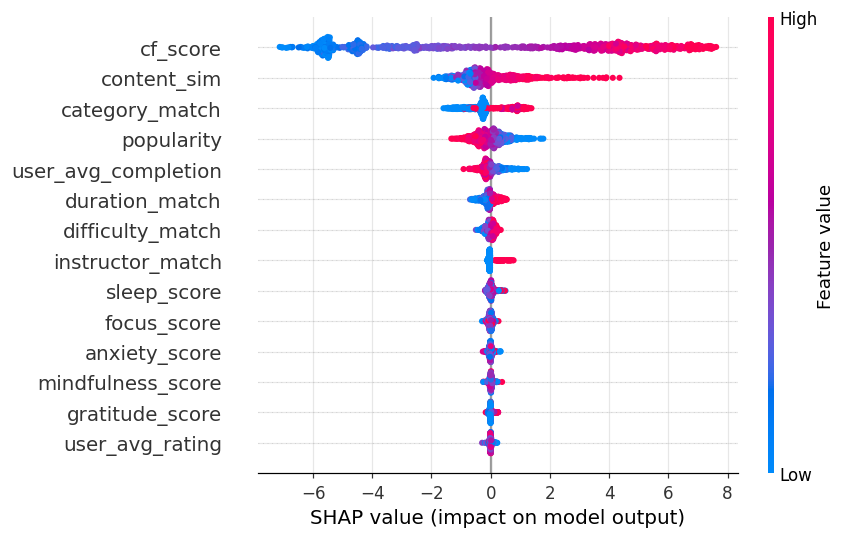

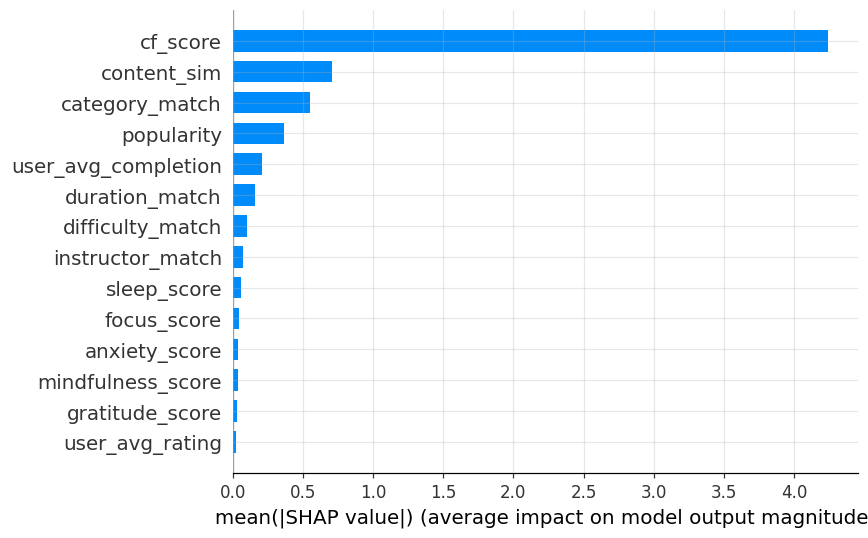


Top ranking features:
             feature  importance
           cf_score    0.638142
        content_sim    0.106768
     category_match    0.083199
         popularity    0.054627
user_avg_completion    0.031812
     duration_match    0.023937
   difficulty_match    0.015096
   instructor_match    0.011267

User 0 → “Midday Mindfulness Meditation”
  Because cf_score (0.59) raised the score; content_sim (0.86) raised the score; category_match (1.50) raised the score; duration_match (0.03) lowered the score.


In [20]:
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

class Explainer:
    def __init__(self, ltr, X_sample, feature_names):
        self.ltr = ltr
        self.feature_names = feature_names
        self.X_sample = X_sample
        self.shap = None
        self.explainer = None
        self.values = None
        try:
            import shap
            self.shap = shap
            self.explainer = shap.TreeExplainer(ltr.model)
            self.values = self.explainer.shap_values(X_sample)
            logger.info("SHAP TreeExplainer ready on %d samples.", len(X_sample))
        except Exception as e:  # noqa: BLE001
            logger.warning("SHAP unavailable (%s); using native feature importances.", e)

    def global_summary(self):
        if self.values is not None:
            self.shap.summary_plot(self.values, self.X_sample,
                                   feature_names=self.feature_names, show=False)
            fig = plt.gcf(); fig.set_size_inches(8, 5); plt.tight_layout()
            fig.savefig(PATHS["shap"] / "shap_summary_beeswarm.png", bbox_inches="tight")
            plt.show(); plt.close(fig)
            # bar version
            self.shap.summary_plot(self.values, self.X_sample, plot_type="bar",
                                   feature_names=self.feature_names, show=False)
            fig = plt.gcf(); fig.set_size_inches(8, 5); plt.tight_layout()
            fig.savefig(PATHS["shap"] / "shap_importance_bar.png", bbox_inches="tight")
            plt.show(); plt.close(fig)
            imp = np.abs(self.values).mean(0)
        else:
            imp = getattr(self.ltr.model, "feature_importances_",
                          np.ones(len(self.feature_names)))
            imp = imp / (imp.sum() + 1e-9)
            order = np.argsort(imp)
            fig, ax = plt.subplots(figsize=(8, 5))
            ax.barh(np.array(self.feature_names)[order], imp[order], color="#5B8FF9")
            ax.set_title("Ranker feature importance (native)")
            plt.tight_layout()
            fig.savefig(PATHS["shap"] / "feature_importance_bar.png", bbox_inches="tight")
            plt.show(); plt.close(fig)
        # persist importances table
        imp_df = pd.DataFrame({"feature": self.feature_names,
                               "importance": imp / (imp.sum() + 1e-9)}
                              ).sort_values("importance", ascending=False)
        imp_df.to_csv(PATHS["shap"] / "feature_importance.csv", index=False)
        return imp_df

    def explain(self, uid, sid, top=4):
        feats = user_item_features(uid, [sid])[0]
        if self.explainer is not None:
            sv = self.explainer.shap_values(feats.reshape(1, -1))[0]
            contrib = sorted(zip(self.feature_names, sv, feats),
                             key=lambda t: -abs(t[1]))[:top]
            parts = []
            for name, val, fv in contrib:
                direction = "raised" if val > 0 else "lowered"
                parts.append(f"{name} ({fv:.2f}) {direction} the score")
            return "Because " + "; ".join(parts) + "."
        # fallback: importance-weighted feature values
        imp = getattr(self.ltr.model, "feature_importances_",
                      np.ones(len(self.feature_names)))
        contrib = sorted(zip(self.feature_names, imp * feats, feats),
                         key=lambda t: -t[1])[:top]
        return "Key drivers: " + ", ".join(f"{n} ({fv:.2f})" for n, _, fv in contrib) + "."

# Fit explainer on a sample of the ranking feature matrix.
_sample_n = min(800, len(X_ltr))
_sample_idx = np.random.RandomState(CFG.seed).choice(len(X_ltr), _sample_n, replace=False)
explainer = Explainer(ltr_model, X_ltr[_sample_idx], FEATURE_NAMES)
importance_df = explainer.global_summary()
print("\nTop ranking features:\n", importance_df.head(8).to_string(index=False))

# Example plain-language explanation for one user's top recommendation
_u = int(test_int.user_id.iloc[0])
_rec = ltr_model.recommend(_u, k=1, exclude=TRAIN_SEEN.get(_u, set()))
if len(_rec):
    print(f"\nUser {_u} → “{sessions.loc[_rec[0],'title']}”")
    print(" ", explainer.explain(_u, int(_rec[0])))

## 13 · Evaluation

We evaluate every model on the **held-out** positive interactions using the standard offline
protocol: for each test user, rank all catalog items the user has **not** seen in training, then
compare the top-K against their held-out likes. We report accuracy metrics (Precision/Recall@K,
MAP, MRR, NDCG, HitRate) and beyond-accuracy metrics (**Coverage**, intra-list **Diversity**,
**Novelty**, **Personalization**) — a strong recommender must beat the popularity baseline on
accuracy *without* collapsing diversity.

In [21]:
def ndcg_at_k(recs, rel, k):
    dcg = sum(1.0 / math.log2(i + 2) for i, s in enumerate(recs[:k]) if s in rel)
    idcg = sum(1.0 / math.log2(i + 2) for i in range(min(len(rel), k)))
    return dcg / idcg if idcg > 0 else 0.0

def average_precision(recs, rel, k):
    if not rel:
        return 0.0
    hits, s = 0, 0.0
    for i, sid in enumerate(recs[:k]):
        if sid in rel:
            hits += 1
            s += hits / (i + 1)
    return s / min(len(rel), k)

def reciprocal_rank(recs, rel):
    for i, sid in enumerate(recs):
        if sid in rel:
            return 1.0 / (i + 1)
    return 0.0

def catalog_metrics(recs_matrix):
    all_items = set()
    div, nov = [], []
    R = np.zeros((len(recs_matrix), N_SESS), dtype=np.float32)
    for i, recs in enumerate(recs_matrix):
        recs = np.asarray(recs, dtype=int)
        all_items.update(recs.tolist())
        R[i, recs] = 1.0
        if len(recs) >= 2:
            E = SESSION_EMB[recs]
            sims = E @ E.T
            iu = np.triu_indices(len(recs), 1)
            div.append(1.0 - float(sims[iu].mean()))
        if len(recs):
            nov.append(float(pop_model.novelty[recs].mean()))
    norms = np.linalg.norm(R, axis=1)
    sim = (R @ R.T) / (np.outer(norms, norms) + 1e-9)
    iu = np.triu_indices(len(recs_matrix), 1)
    personalization = 1.0 - float(sim[iu].mean()) if len(recs_matrix) > 1 else 0.0
    return {"Coverage": len(all_items) / N_SESS,
            "Diversity": float(np.mean(div)) if div else 0.0,
            "Novelty": float(np.mean(nov)) if nov else 0.0,
            "Personalization": personalization}

def evaluate_all(models, users_eval, k_values=CFG.k_values):
    max_k = max(k_values)
    results, rec_store = {}, {}
    for name, model in models.items():
        rows, recs_matrix = [], []
        for uid in tqdm(users_eval, desc=f"eval:{name}", leave=False):
            rel = TEST_POS.get(uid, set())
            exclude = TRAIN_SEEN.get(uid, set())
            recs = top_k_from_scores(model.score_all(uid), max_k, exclude)
            recs_matrix.append(recs)
            m = {}
            for k in k_values:
                inter = len(set(recs[:k].tolist()) & rel)
                m[f"Precision@{k}"] = inter / k
                m[f"Recall@{k}"] = inter / len(rel) if rel else 0.0
                m[f"HitRate@{k}"] = 1.0 if inter > 0 else 0.0
                m[f"NDCG@{k}"] = ndcg_at_k(recs.tolist(), rel, k)
            m["MAP"] = average_precision(recs.tolist(), rel, max_k)
            m["MRR"] = reciprocal_rank(recs.tolist(), rel)
            rows.append(m)
        agg = pd.DataFrame(rows).mean().to_dict()
        agg.update(catalog_metrics(recs_matrix))
        results[name] = agg
        rec_store[name] = recs_matrix
    return pd.DataFrame(results).T, rec_store

# Choose evaluation users (reproducible sample of users with held-out positives)
eval_users = sorted(TEST_POS.keys())
rs = np.random.RandomState(CFG.seed)
if len(eval_users) > CFG.eval_user_sample:
    eval_users = sorted(rs.choice(eval_users, CFG.eval_user_sample, replace=False).tolist())
logger.info("Evaluating on %d users.", len(eval_users))

MODELS = {"Popularity": pop_model, "Content": content_model,
          "CollaborativeFiltering": cf_model, "LearningToRank": ltr_model}
with Timer("Evaluating all models"):
    eval_df, REC_STORE = evaluate_all(MODELS, eval_users)

eval_df = eval_df.round(4)
eval_df.to_csv(PATHS["outputs"] / "Recommendation_Evaluation.csv")
ordered_cols = [f"Precision@{k}" for k in CFG.k_values] + \
               [f"Recall@{k}" for k in CFG.k_values] + \
               ["MAP", "MRR"] + [f"NDCG@{k}" for k in CFG.k_values] + \
               [f"HitRate@{k}" for k in CFG.k_values] + \
               ["Coverage", "Diversity", "Novelty", "Personalization"]
ordered_cols = [c for c in ordered_cols if c in eval_df.columns]
print("\n===== MODEL COMPARISON =====\n")
print(eval_df[ordered_cols].to_string())

18:36:55 | INFO    | Evaluating on 1200 users.


INFO:mindguide:Evaluating on 1200 users.


18:36:55 | INFO    | ▶ Evaluating all models …


INFO:mindguide:▶ Evaluating all models …


eval:Popularity:   0%|          | 0/1200 [00:00<?, ?it/s]

...

eval:CollaborativeFiltering:   0%|          | 0/1200 [00:00<?, ?it/s]

eval:LearningToRank:   0%|          | 0/1200 [00:00<?, ?it/s]

18:37:14 | INFO    | ■ Evaluating all models done in 18.7s


INFO:mindguide:■ Evaluating all models done in 18.7s



===== MODEL COMPARISON =====

                        Precision@5  Precision@10  Recall@5  Recall@10     MAP     MRR  NDCG@5  NDCG@10  HitRate@5  HitRate@10  Coverage  Diversity  Novelty  Personalization
Popularity                   0.0102        0.0088    0.0245     0.0418  0.0134  0.0278  0.0176   0.0245     0.0508      0.0867    0.0366     0.2827   0.0677           0.0853
Content                      0.0210        0.0192    0.0526     0.0928  0.0306  0.0615  0.0385   0.0545     0.1042      0.1825    0.8225     0.2341   0.3065           0.8591
CollaborativeFiltering       0.0187        0.0164    0.0445     0.0769  0.0275  0.0561  0.0344   0.0473     0.0892      0.1533    1.0000     0.4182   0.3622           0.9705
LearningToRank               0.0230        0.0207    0.0497     0.0900  0.0305  0.0667  0.0390   0.0553     0.1108      0.1892    1.0000     0.3978   0.4303           0.9727


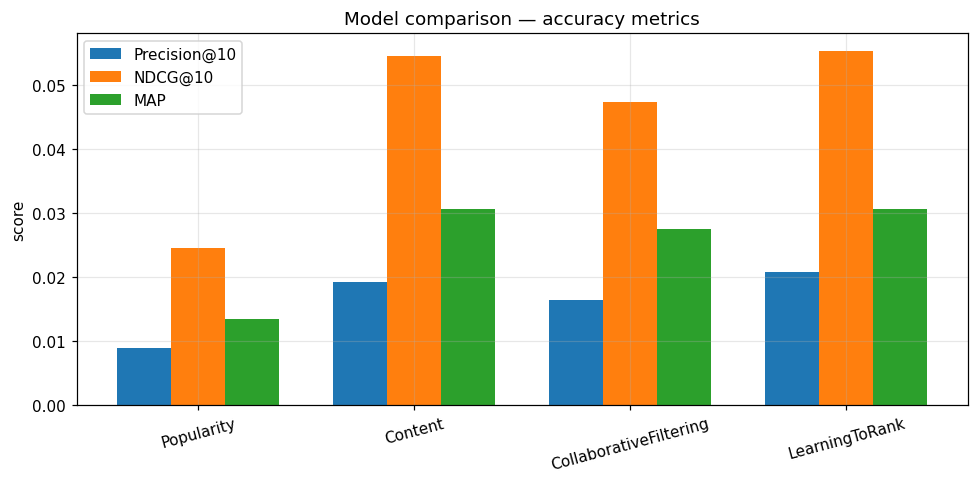

In [22]:
# --- Comparison bar chart (Precision@10 / NDCG@10 / MAP) ----------------------
metric_show = [c for c in [f"Precision@{max(CFG.k_values)}",
                           f"NDCG@{max(CFG.k_values)}", "MAP"] if c in eval_df.columns]
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(eval_df.index)); w = 0.25
for j, met in enumerate(metric_show):
    ax.bar(x + j * w, eval_df[met].values, w, label=met)
ax.set_xticks(x + w); ax.set_xticklabels(eval_df.index, rotation=15)
ax.set_ylabel("score"); ax.set_title("Model comparison — accuracy metrics")
ax.legend()
plt.tight_layout()
fig.savefig(PATHS["figures"] / "model_comparison.png", bbox_inches="tight")
plt.show(); plt.close(fig)

## 14 · Visualizations

A gallery of professional figures covering the catalog, the embedding space, clustering,
interaction structure, and recommendation quality. Every figure is saved to `mindguide_ai/figures/`.

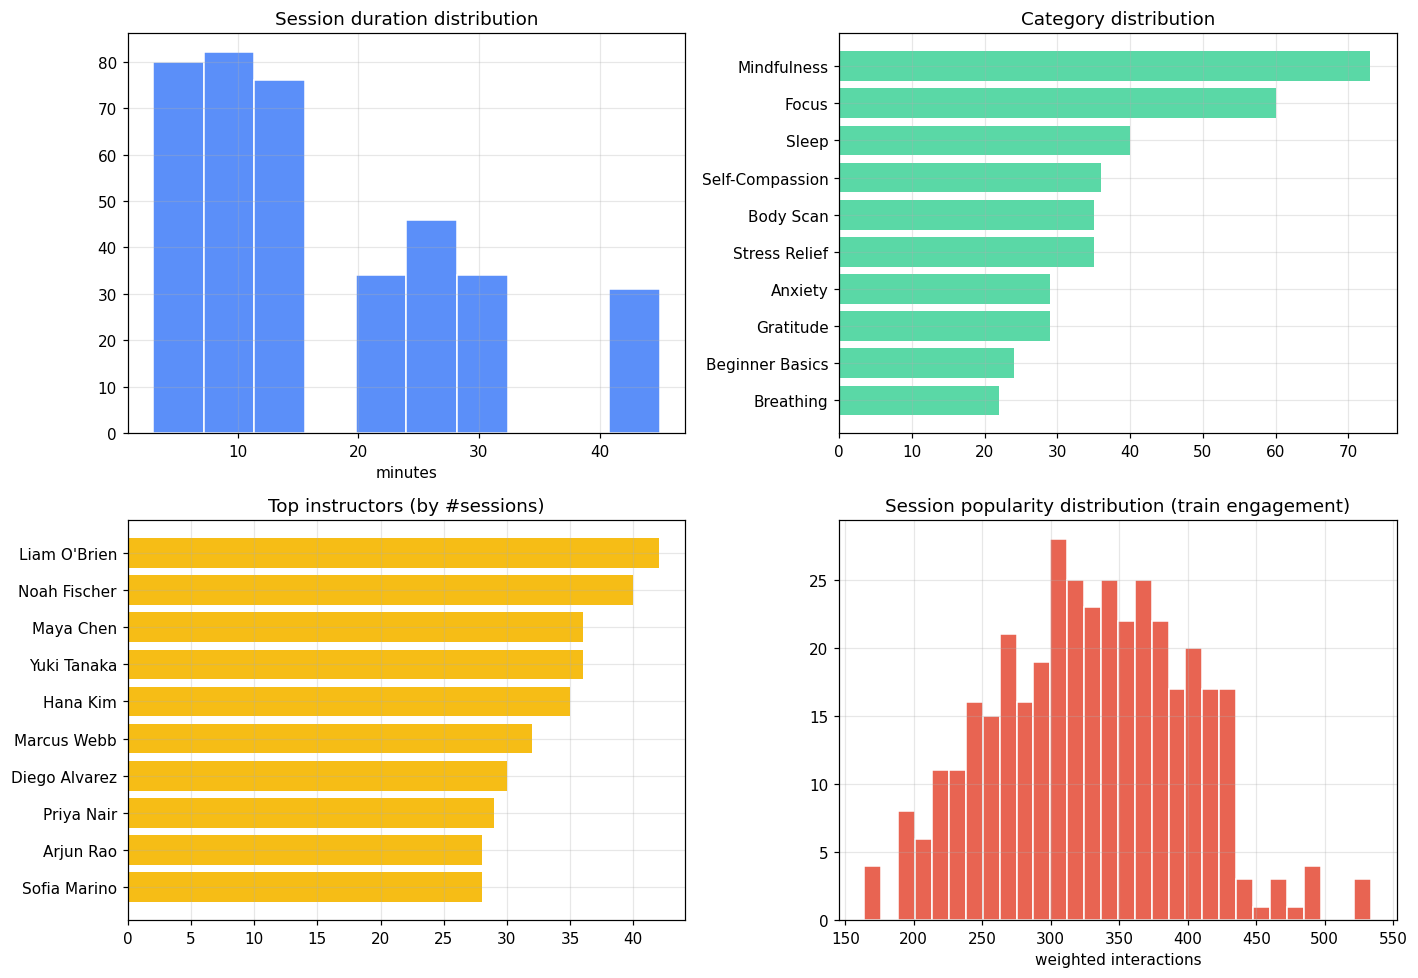

In [23]:
def _save(fig, name):
    fig.savefig(PATHS["figures"] / name, bbox_inches="tight", dpi=120)

# ---- Catalog distributions ---------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0, 0].hist(sessions.duration_min, bins=len(CFG.durations), color="#5B8FF9", edgecolor="w")
axes[0, 0].set_title("Session duration distribution"); axes[0, 0].set_xlabel("minutes")

cat_counts = sessions.category.value_counts()
axes[0, 1].barh(cat_counts.index[::-1], cat_counts.values[::-1], color="#5AD8A6")
axes[0, 1].set_title("Category distribution")

top_instr = sessions.instructor.value_counts().head(10)
axes[1, 0].barh(top_instr.index[::-1], top_instr.values[::-1], color="#F6BD16")
axes[1, 0].set_title("Top instructors (by #sessions)")

axes[1, 1].hist(pop_model.pop, bins=30, color="#E86452", edgecolor="w")
axes[1, 1].set_title("Session popularity distribution (train engagement)")
axes[1, 1].set_xlabel("weighted interactions")
plt.tight_layout(); _save(fig, "catalog_distributions.png"); plt.show(); plt.close(fig)

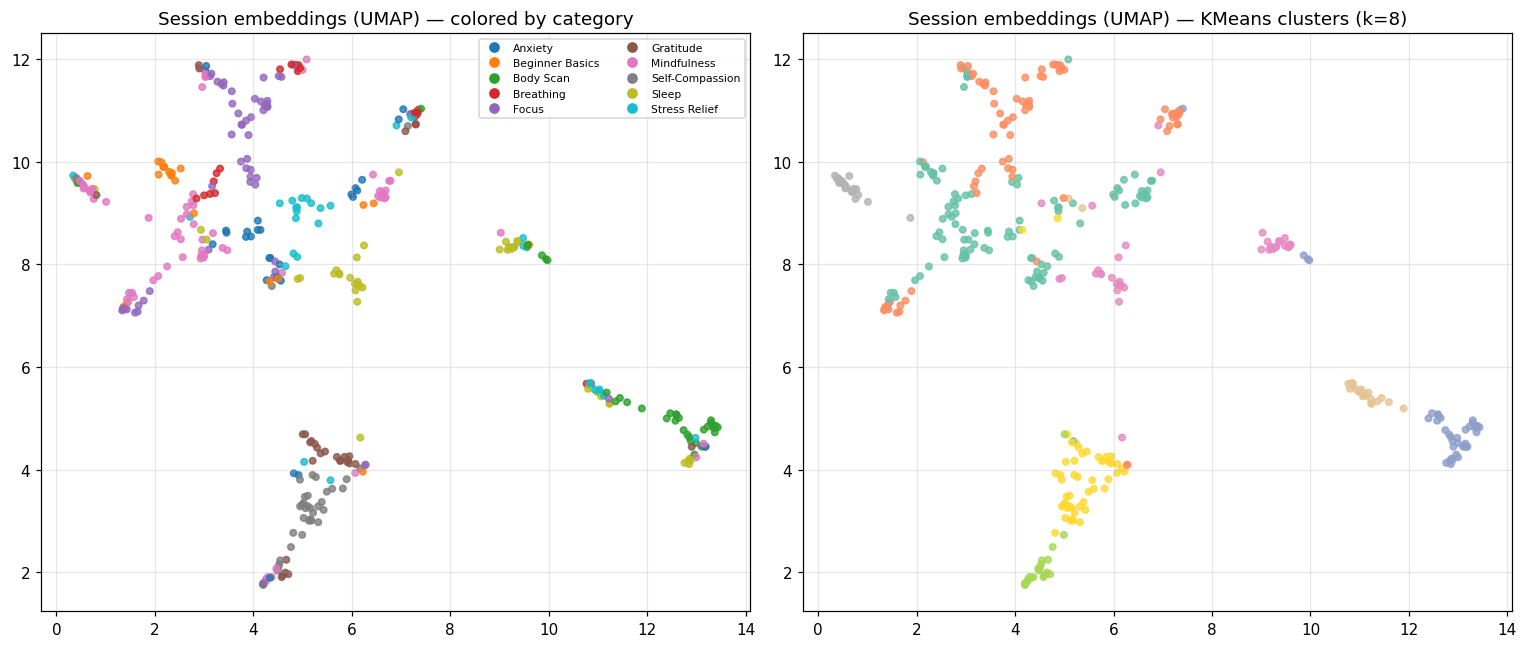

In [24]:
# ---- Embedding projection + meditation clustering ---------------------------
from sklearn.cluster import KMeans

def project_2d(X):
    if OPT.get("umap"):
        try:
            import umap
            return umap.UMAP(n_components=2, random_state=CFG.seed,
                             n_neighbors=15, min_dist=0.1).fit_transform(X), "UMAP"
        except Exception as e:  # noqa: BLE001
            logger.warning("UMAP failed (%s); using PCA.", e)
    from sklearn.decomposition import PCA
    return PCA(n_components=2, random_state=CFG.seed).fit_transform(X), "PCA"

emb_2d, proj_name = project_2d(SESSION_EMB)
n_clusters = min(8, len(sessions))
sess_clusters = KMeans(n_clusters=n_clusters, random_state=CFG.seed, n_init=10).fit_predict(SESSION_EMB)
sessions["cluster"] = sess_clusters

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cats = sessions.category.astype("category")
sc0 = axes[0].scatter(emb_2d[:, 0], emb_2d[:, 1], c=cats.cat.codes, cmap="tab10", s=18, alpha=0.8)
axes[0].set_title(f"Session embeddings ({proj_name}) — colored by category")
handles = [plt.Line2D([], [], marker="o", ls="", color=plt.cm.tab10(i / 10), label=c)
           for i, c in enumerate(cats.cat.categories)]
axes[0].legend(handles=handles, fontsize=7, loc="best", ncol=2)
axes[1].scatter(emb_2d[:, 0], emb_2d[:, 1], c=sess_clusters, cmap="Set2", s=18, alpha=0.8)
axes[1].set_title(f"Session embeddings ({proj_name}) — KMeans clusters (k={n_clusters})")
plt.tight_layout(); _save(fig, "embedding_projection.png"); plt.show(); plt.close(fig)

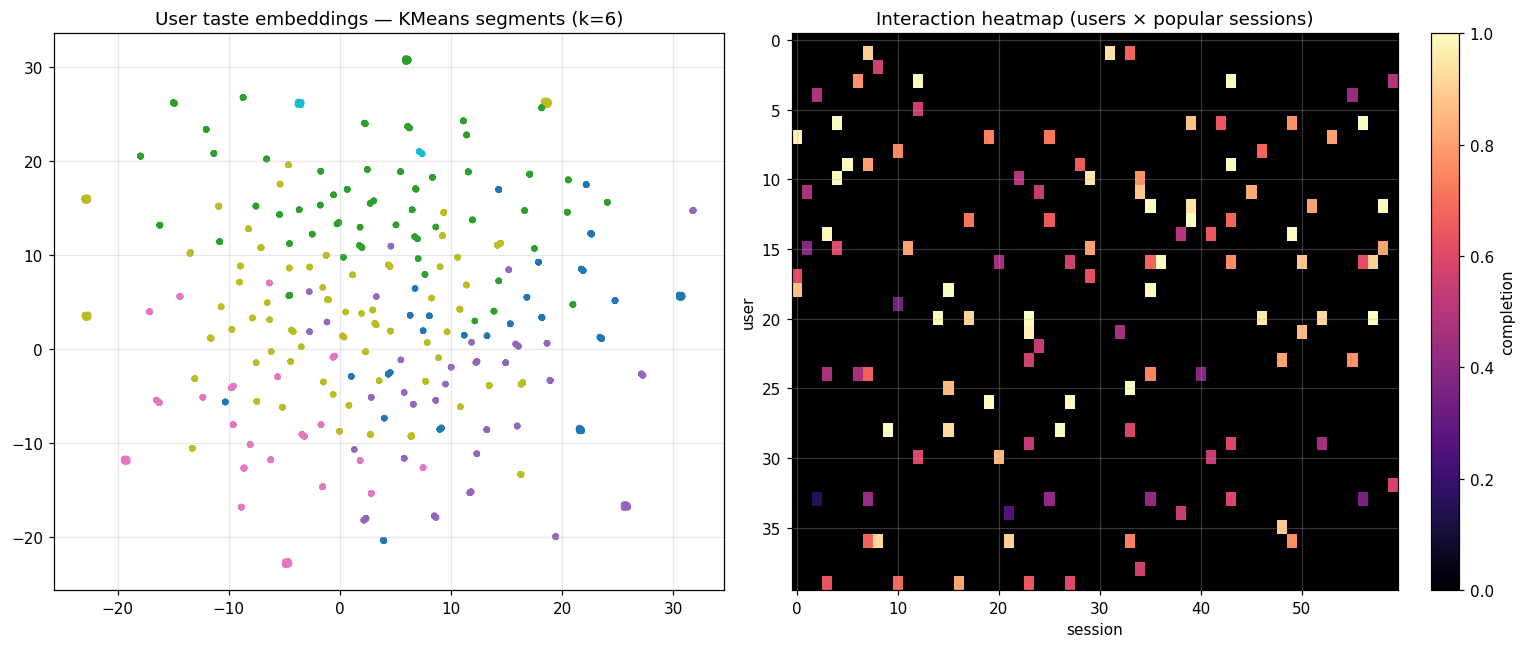

In [25]:
# ---- User clustering + interaction heatmap ----------------------------------
user_2d, _ = project_2d(USER_TASTE)
u_clusters = KMeans(n_clusters=6, random_state=CFG.seed, n_init=10).fit_predict(USER_TASTE)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(user_2d[:, 0], user_2d[:, 1], c=u_clusters, cmap="tab10", s=10, alpha=0.6)
axes[0].set_title("User taste embeddings — KMeans segments (k=6)")

# heatmap: sample of users x most-popular sessions (completion values)
samp_u = np.sort(rs.choice(N_USERS, min(40, N_USERS), replace=False))
samp_s = np.argsort(-pop_model.pop)[:min(60, N_SESS)]
H = np.zeros((len(samp_u), len(samp_s)))
comp_lookup = train_int.set_index(["user_id", "session_id"]).completion.to_dict()
for a, u in enumerate(samp_u):
    for b, s in enumerate(samp_s):
        H[a, b] = comp_lookup.get((u, int(s)), 0.0)
im = axes[1].imshow(H, aspect="auto", cmap="magma")
axes[1].set_title("Interaction heatmap (users × popular sessions)")
axes[1].set_xlabel("session"); axes[1].set_ylabel("user")
fig.colorbar(im, ax=axes[1], fraction=0.046, label="completion")
plt.tight_layout(); _save(fig, "user_clusters_heatmap.png"); plt.show(); plt.close(fig)

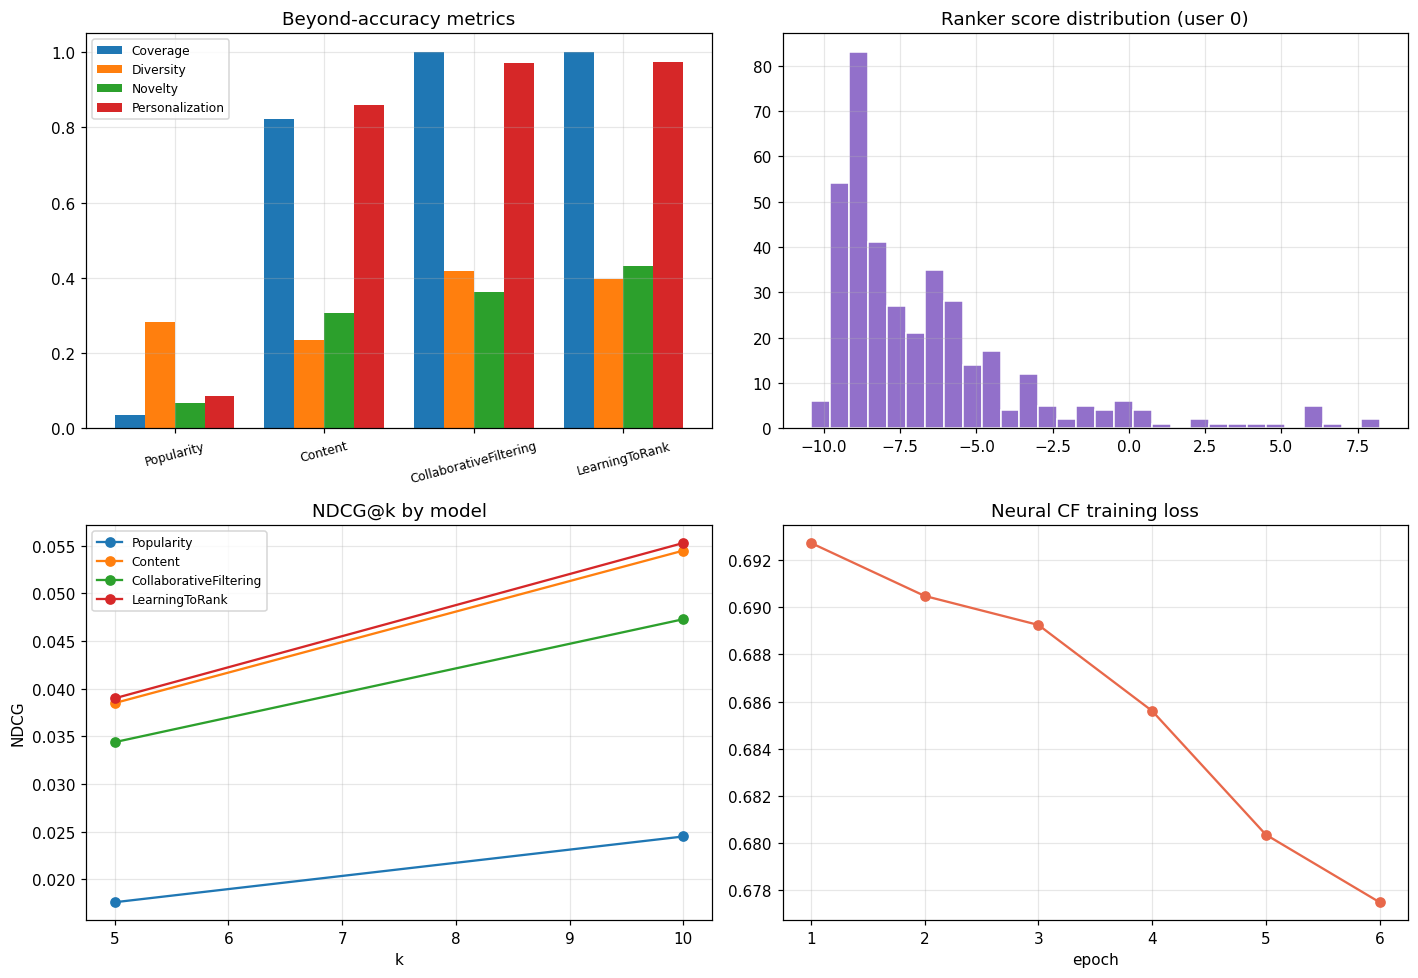

All figures saved to mindguide_ai/figures


In [26]:
# ---- Beyond-accuracy bars, score distribution, NDCG@k, training curve -------
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

beyond = ["Coverage", "Diversity", "Novelty", "Personalization"]
beyond = [b for b in beyond if b in eval_df.columns]
bx = np.arange(len(eval_df.index)); bw = 0.2
for j, met in enumerate(beyond):
    axes[0, 0].bar(bx + j * bw, eval_df[met].values, bw, label=met)
axes[0, 0].set_xticks(bx + 1.5 * bw); axes[0, 0].set_xticklabels(eval_df.index, rotation=15, fontsize=8)
axes[0, 0].set_title("Beyond-accuracy metrics"); axes[0, 0].legend(fontsize=8)

# score distribution for a representative user (LTR)
rep_u = eval_users[0]
axes[0, 1].hist(ltr_model.score_all(rep_u), bins=30, color="#9270CA", edgecolor="w")
axes[0, 1].set_title(f"Ranker score distribution (user {rep_u})")

# NDCG@k across models
ndcg_cols = [f"NDCG@{k}" for k in CFG.k_values if f"NDCG@{k}" in eval_df.columns]
for name in eval_df.index:
    axes[1, 0].plot(list(CFG.k_values), [eval_df.loc[name, c] for c in ndcg_cols],
                    marker="o", label=name)
axes[1, 0].set_xlabel("k"); axes[1, 0].set_ylabel("NDCG"); axes[1, 0].set_title("NDCG@k by model")
axes[1, 0].legend(fontsize=8)

# training curve (NCF if available, else ranker native importances as proxy)
if NCF_MODEL and NCF_MODEL.get("curve"):
    axes[1, 1].plot(range(1, len(NCF_MODEL["curve"]) + 1), NCF_MODEL["curve"],
                    marker="o", color="#E8684A")
    axes[1, 1].set_title("Neural CF training loss"); axes[1, 1].set_xlabel("epoch")
else:
    imp = importance_df.set_index("feature")["importance"]
    axes[1, 1].barh(imp.index[::-1], imp.values[::-1], color="#5B8FF9")
    axes[1, 1].set_title("Ranker feature importance")
plt.tight_layout(); _save(fig, "quality_dashboard.png"); plt.show(); plt.close(fig)
print("All figures saved to", PATHS["figures"])

## 15 · Save All Deliverables

Every required artifact is written to disk: processed data, user profiles, the interaction table,
per-user top-N recommendations, embeddings, and all trained models.

In [27]:
# processed catalog (used by the dashboard)
sessions.to_csv(PATHS["processed"] / "sessions_processed.csv", index=False)

# User_Profiles.csv (list columns JSON-encoded for portability)
users_out = users.copy()
for col in ["preferred_categories", "preferred_instructors", "goals",
            "liked_sessions", "disliked_sessions", "skipped_sessions"]:
    users_out[col] = users_out[col].map(json.dumps)
users_out.to_csv(PATHS["outputs"] / "User_Profiles.csv", index=False)

# Interaction_Matrix.csv (long/COO form of the user×item matrix)
interactions.to_csv(PATHS["outputs"] / "Interaction_Matrix.csv", index=False)

# Popularity artifact for the dashboard
save_pickle({"score_vec": pop_model.score_vec, "novelty": pop_model.novelty},
            PATHS["outputs"] / "popularity.pkl")

# Top_Recommendations.csv — top-10 from the ranker for a sample of users
export_users = list(range(min(N_USERS, 1000)))
top_rows = []
with Timer(f"Generating top-10 recommendations for {len(export_users)} users"):
    for uid in tqdm(export_users, desc="top-recs"):
        recs = ltr_model.recommend(uid, k=10, exclude=TRAIN_SEEN.get(uid, set()))
        for rank, sid in enumerate(recs, 1):
            top_rows.append(dict(
                user_id=uid, rank=rank, session_id=int(sid),
                title=sessions.loc[sid, "title"], category=sessions.loc[sid, "category"],
                duration_min=int(sessions.loc[sid, "duration_min"]),
                instructor=sessions.loc[sid, "instructor"]))
top_recs_df = pd.DataFrame(top_rows)
top_recs_df.to_csv(PATHS["outputs"] / "Top_Recommendations.csv", index=False)

logger.info("Deliverables written to %s and %s", PATHS["outputs"], PATHS["models"])
print("Saved:")
for f in ["Top_Recommendations.csv", "Recommendation_Evaluation.csv",
          "User_Profiles.csv", "Interaction_Matrix.csv", "popularity.pkl"]:
    p = PATHS["outputs"] / f
    print(f"  outputs/{f:<32} {p.stat().st_size/1024:8.1f} KB")
for f in ["Content_Model.pkl", "Collaborative_Filtering_Model.pkl", "Ranking_Model.pkl"]:
    p = PATHS["models"] / f
    print(f"  models/{f:<33} {p.stat().st_size/1024:8.1f} KB")
top_recs_df.head(8)

18:38:37 | INFO    | ▶ Generating top-10 recommendations for 1000 users …


INFO:mindguide:▶ Generating top-10 recommendations for 1000 users …


top-recs:   0%|          | 0/1000 [00:00<?, ?it/s]

18:38:50 | INFO    | ■ Generating top-10 recommendations for 1000 users done in 12.7s


INFO:mindguide:■ Generating top-10 recommendations for 1000 users done in 12.7s


18:38:50 | INFO    | Deliverables written to mindguide_ai/outputs and mindguide_ai/models


INFO:mindguide:Deliverables written to mindguide_ai/outputs and mindguide_ai/models


Saved:
  outputs/Top_Recommendations.csv             611.1 KB
  outputs/Recommendation_Evaluation.csv         0.6 KB
  outputs/User_Profiles.csv                   700.2 KB
  outputs/Interaction_Matrix.csv             1785.3 KB
  outputs/popularity.pkl                        6.2 KB
  models/Content_Model.pkl                   6574.7 KB
  models/Collaborative_Filtering_Model.pkl   1096.0 KB
  models/Ranking_Model.pkl                   1034.1 KB


,user_id,rank,session_id,title,category,duration_min,instructor
0,0,1,334,Midday Mindfulness Meditation,Mindfulness,25,Liam O'Brien
1,0,2,18,8-Minute Mindfulness Practice,Mindfulness,8,Arjun Rao
2,0,3,104,Mettā for Mindfulness,Mindfulness,3,Arjun Rao
3,0,4,1,A 10-Minute Mindfulness Journey,Anxiety,10,Noah Fischer
4,0,5,28,A 3-Minute Meditation Journey,Mindfulness,3,Aisha Bello
5,0,6,276,Deep Mindfulness with Zen,Mindfulness,25,Maya Chen
6,0,7,74,Mindfulness Vipassanā,Mindfulness,5,Hana Kim
7,0,8,39,25-Minute Stress Relief Practice,Stress Relief,25,Priya Nair


## 16 · Streamlit Dashboard (auto-generated)

The notebook writes a complete, self-contained Streamlit app to `mindguide_ai/dashboard/app.py`.
It loads the saved artifacts and offers: user-profile selection, live preference editing,
top-N recommendations with explanations, semantic search, category/duration filtering, interactive
charts, the model-comparison table, and a CSV export button. The final cell shows how to serve it
from Colab.

In [28]:
APP_CODE = r'''
import json, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import streamlit as st

st.set_page_config(page_title="MindGuide AI", page_icon="🧘", layout="wide")
ROOT = Path(__file__).resolve().parent.parent
PROC = ROOT / "data" / "processed"
EMB  = ROOT / "data" / "embeddings"
OUT  = ROOT / "outputs"

def _minmax(a):
    a = np.asarray(a, dtype=float)
    return (a - a.min()) / (np.ptp(a) + 1e-9)

@st.cache_data
def load_sessions():
    df = pd.read_csv(PROC / "sessions_processed.csv").sort_values("session_id").reset_index(drop=True)
    return df

@st.cache_resource
def load_artifacts():
    with open(EMB / "Session_Embeddings.pkl", "rb") as f:
        emb = pickle.load(f)["session"]
    with open(OUT / "popularity.pkl", "rb") as f:
        pop = pickle.load(f)
    users = pd.read_csv(OUT / "User_Profiles.csv")
    try:
        eval_df = pd.read_csv(OUT / "Recommendation_Evaluation.csv", index_col=0)
    except Exception:
        eval_df = None
    return emb, pop, users, eval_df

@st.cache_resource
def get_encoder(dim):
    try:
        from sentence_transformers import SentenceTransformer
        m = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
        if m.get_sentence_embedding_dimension() == dim:
            return m
    except Exception:
        pass
    return None

sessions = load_sessions()
EMB_MAT, POP, USERS, EVAL_DF = load_artifacts()
CATS = sorted(sessions.category.unique())

def category_profile(cats):
    idx = sessions.index[sessions.category.isin(cats)].to_numpy()
    if len(idx) == 0:
        idx = sessions.index.to_numpy()
    v = EMB_MAT[idx].mean(0)
    n = np.linalg.norm(v)
    return v / n if n > 0 else v

def recommend(cats, pref_dur, n=10, cat_filter=None, dur_range=None):
    prof = category_profile(cats)
    sem = EMB_MAT @ prof
    catmatch = sessions.category.isin(cats).to_numpy().astype(float)
    score = 0.60 * _minmax(sem) + 0.25 * catmatch + 0.15 * _minmax(POP["score_vec"])
    if pref_dur:
        score = score + 0.10 * np.exp(-((sessions.duration_min.to_numpy() - pref_dur) ** 2) / 72.0)
    mask = np.ones(len(sessions), dtype=bool)
    if cat_filter:
        mask &= sessions.category.isin(cat_filter).to_numpy()
    if dur_range:
        mask &= sessions.duration_min.between(dur_range[0], dur_range[1]).to_numpy()
    score = np.where(mask, score, -np.inf)
    idx = np.argsort(-score)[:n]
    out = sessions.iloc[idx][["session_id", "title", "category", "duration_min",
                              "instructor", "difficulty"]].copy()
    out["score"] = score[idx].round(3)
    out["_sem"] = _minmax(sem)[idx].round(3)
    out["_cat"] = catmatch[idx]
    return out

def explain(row, cats):
    bits = []
    if row["_cat"] > 0:
        bits.append("matches a preferred category")
    if row["_sem"] > 0.6:
        bits.append("semantically close to your interests")
    bits.append(f"popularity-supported")
    return "Recommended because it " + ", ".join(bits) + "."

st.title("🧘 MindGuide AI — Meditation Recommender")
st.caption("Hybrid content + popularity recommender with semantic search and explanations.")

with st.sidebar:
    st.header("Your profile")
    ids = ["(new user)"] + USERS.user_id.astype(str).tolist()[:500]
    picked = st.selectbox("Load an existing user", ids)
    default_cats = CATS[:2]
    default_dur = 15
    if picked != "(new user)":
        row = USERS[USERS.user_id == int(picked)].iloc[0]
        try:
            default_cats = json.loads(row["preferred_categories"])
        except Exception:
            pass
        default_dur = int(row["preferred_duration"])
        st.write(f"Experience: **{row['experience_level']}**  ·  "
                 f"Weekly freq: **{row['weekly_frequency']}**")
    cats = st.multiselect("Preferred categories", CATS, default=default_cats)
    pref_dur = st.slider("Preferred duration (min)", 3, 45, default_dur)
    top_n = st.slider("How many recommendations", 3, 20, 8)
    st.divider()
    st.subheader("Filters")
    cat_filter = st.multiselect("Only these categories", CATS, default=[])
    dur_range = st.slider("Duration range", 3, 45, (3, 45))

if not cats:
    cats = default_cats

tab1, tab2, tab3 = st.tabs(["✨ Recommendations", "🔎 Semantic search", "📊 Model comparison"])

with tab1:
    recs = recommend(cats, pref_dur, top_n, cat_filter or None, dur_range)
    st.subheader(f"Top {len(recs)} for you")
    for _, r in recs.iterrows():
        with st.container(border=True):
            c1, c2 = st.columns([4, 1])
            c1.markdown(f"**{r['title']}**  \n"
                        f"{r['category']} · {r['duration_min']} min · {r['instructor']} · {r['difficulty']}")
            c1.caption(explain(r, cats))
            c2.metric("score", f"{r['score']:.2f}")
    st.bar_chart(recs.set_index("title")["score"])
    st.download_button("⬇ Export these recommendations (CSV)",
                       recs.drop(columns=["_sem", "_cat"]).to_csv(index=False),
                       "my_recommendations.csv", "text/csv")

with tab2:
    q = st.text_input("Describe what you want",
                      "a 15 minute meditation for anxiety before bed")
    if q:
        enc = get_encoder(EMB_MAT.shape[1])
        if enc is not None:
            qv = enc.encode([q], normalize_embeddings=True)[0]
            sims = EMB_MAT @ qv
        else:
            terms = [t for t in q.lower().split() if len(t) > 2]
            hay = (sessions.title + " " + sessions.description).str.lower()
            sims = hay.apply(lambda h: sum(t in h for t in terms)).to_numpy(dtype=float)
        idx = np.argsort(-sims)[:8]
        res = sessions.iloc[idx][["title", "category", "duration_min", "instructor"]].copy()
        res["match"] = np.round(sims[idx], 3)
        st.dataframe(res, use_container_width=True)

with tab3:
    if EVAL_DF is not None:
        st.dataframe(EVAL_DF, use_container_width=True)
        acc = [c for c in EVAL_DF.columns if c.startswith("NDCG") or c.startswith("Precision")]
        if acc:
            st.bar_chart(EVAL_DF[acc])
    else:
        st.info("Run the evaluation cell to populate model comparison.")
'''

app_path = PATHS["dashboard"] / "app.py"
app_path.write_text(APP_CODE, encoding="utf-8")
(PATHS["dashboard"] / "requirements.txt").write_text(
    "streamlit\npandas\nnumpy\nsentence-transformers\n", encoding="utf-8")
logger.info("Streamlit app written to %s (%d chars).", app_path, len(APP_CODE))
print("Dashboard generated at", app_path)

18:38:50 | INFO    | Streamlit app written to mindguide_ai/dashboard/app.py (6132 chars).


INFO:mindguide:Streamlit app written to mindguide_ai/dashboard/app.py (6132 chars).


Dashboard generated at mindguide_ai/dashboard/app.py


In [29]:
# --- How to serve the dashboard from Colab -----------------------------------
# Streamlit needs a public tunnel in Colab. Two easy options are shown; neither
# blocks the notebook. Run ONE of them in a fresh cell.

launch_instructions = f"""
To launch the dashboard from Colab, run this in a NEW cell:

    # Option A — localtunnel (no signup):
    !npm install -g localtunnel >/dev/null 2>&1
    !streamlit run {app_path} &>/content/logs.txt &
    !sleep 5 && npx localtunnel --port 8501
    # (open the printed URL; the tunnel password is your Colab VM's public IP,
    #  shown by: !curl -s https://loca.lt/mytunnelpassword )

    # Option B — pyngrok (needs a free ngrok authtoken):
    from pyngrok import ngrok
    ngrok.set_auth_token("YOUR_TOKEN")
    import subprocess, time
    subprocess.Popen(["streamlit", "run", "{app_path}",
                      "--server.port", "8501", "--server.headless", "true"])
    time.sleep(6)
    print("Public URL:", ngrok.connect(8501).public_url)
"""
print(launch_instructions)


To launch the dashboard from Colab, run this in a NEW cell:

    # Option A — localtunnel (no signup):
    !npm install -g localtunnel >/dev/null 2>&1
    !streamlit run mindguide_ai/dashboard/app.py &>/content/logs.txt &
    !sleep 5 && npx localtunnel --port 8501
    # (open the printed URL; the tunnel password is your Colab VM's public IP,
    #  shown by: !curl -s https://loca.lt/mytunnelpassword )

    # Option B — pyngrok (needs a free ngrok authtoken):
    from pyngrok import ngrok
    ngrok.set_auth_token("YOUR_TOKEN")
    import subprocess, time
    subprocess.Popen(["streamlit", "run", "mindguide_ai/dashboard/app.py",
                      "--server.port", "8501", "--server.headless", "true"])
    time.sleep(6)
    print("Public URL:", ngrok.connect(8501).public_url)



## 17 · Final Report (PDF)

An auto-generated `Final_Report.pdf` summarizing the system, the model-comparison table and key
figures — built with ReportLab, falling back to a Matplotlib PDF if ReportLab is unavailable.

In [30]:
_best_metric = f"NDCG@{max(CFG.k_values)}"
_best_model = eval_df[_best_metric].idxmax() if _best_metric in eval_df.columns else eval_df.index[0]
SUMMARY = (
    f"MindGuide AI is a hybrid meditation recommender built from {len(sessions)} sessions "
    f"(grounded in real technique text) and {N_USERS} reproducible synthetic users with "
    f"{len(interactions)} interactions. It combines content-based retrieval, collaborative "
    f"filtering ({cf_model.backend}), a popularity baseline and a {ltr_model.backend} "
    f"learning-to-rank model, with SHAP explanations, semantic search and cold-start handling. "
    f"On held-out data the strongest model by {_best_metric} is '{_best_model}'.")

_pdf_metrics = [c for c in ["Precision@10", "Recall@10", _best_metric, "MAP", "MRR",
                            "Coverage", "Diversity", "Personalization"] if c in eval_df.columns]

def build_pdf_report():
    path = PATHS["outputs"] / "Final_Report.pdf"
    try:
        from reportlab.lib.pagesizes import A4
        from reportlab.lib.units import cm
        from reportlab.lib import colors
        from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer,
                                        Table, TableStyle, Image)
        from reportlab.lib.styles import getSampleStyleSheet
        styles = getSampleStyleSheet()
        doc = SimpleDocTemplate(str(path), pagesize=A4, title="MindGuide AI Report")
        story = [Paragraph("MindGuide AI — Final Report", styles["Title"]),
                 Spacer(1, 10), Paragraph(SUMMARY, styles["BodyText"]), Spacer(1, 14),
                 Paragraph("Model comparison (held-out evaluation)", styles["Heading2"])]
        header = ["Metric"] + list(eval_df.index)
        data = [header] + [[m] + [f"{eval_df.loc[md, m]:.3f}" for md in eval_df.index]
                           for m in _pdf_metrics]
        t = Table(data, hAlign="LEFT")
        t.setStyle(TableStyle([
            ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#5B8FF9")),
            ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
            ("FONTSIZE", (0, 0), (-1, -1), 8),
            ("GRID", (0, 0), (-1, -1), 0.4, colors.grey),
            ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.HexColor("#F2F6FF")])]))
        story += [t, Spacer(1, 14)]
        for img, h in [("model_comparison.png", 9), ("catalog_distributions.png", 12),
                       ("embedding_projection.png", 8)]:
            p = PATHS["figures"] / img
            if p.exists():
                story += [Image(str(p), width=16 * cm, height=h * cm), Spacer(1, 10)]
        doc.build(story)
        return path, "reportlab"
    except Exception as e:  # noqa: BLE001
        logger.warning("ReportLab unavailable (%s); using Matplotlib PDF.", e)
        from matplotlib.backends.backend_pdf import PdfPages
        with PdfPages(path) as pdf:
            fig = plt.figure(figsize=(8.3, 11.7)); plt.axis("off")
            plt.text(0.05, 0.95, "MindGuide AI — Final Report", fontsize=18, weight="bold",
                     va="top")
            plt.text(0.05, 0.88, SUMMARY, fontsize=10, va="top", wrap=True)
            tbl = plt.table(cellText=[[m] + [f"{eval_df.loc[md, m]:.3f}" for md in eval_df.index]
                                      for m in _pdf_metrics],
                            colLabels=["Metric"] + list(eval_df.index),
                            loc="center", cellLoc="center")
            tbl.scale(1, 1.4); pdf.savefig(fig); plt.close(fig)
            for img in ["model_comparison.png", "catalog_distributions.png",
                        "embedding_projection.png"]:
                p = PATHS["figures"] / img
                if p.exists():
                    fig = plt.figure(figsize=(8.3, 6)); plt.axis("off")
                    plt.imshow(plt.imread(p)); pdf.savefig(fig); plt.close(fig)
        return path, "matplotlib"

report_path, report_backend = build_pdf_report()
logger.info("Final report written via %s: %s", report_backend, report_path)
print("PDF report:", report_path)

18:38:51 | INFO    | Final report written via reportlab: mindguide_ai/outputs/Final_Report.pdf


INFO:mindguide:Final report written via reportlab: mindguide_ai/outputs/Final_Report.pdf


PDF report: mindguide_ai/outputs/Final_Report.pdf


## 18 · Final Demonstration — Three Users, Explained

We put the system through the prompt's scenarios. For each natural-language profile we run both
**semantic search** (free-text intent) and the **cold-start** recommender (structured onboarding),
then explain the result.

In [31]:
def demonstrate(label, description, categories, duration):
    print("=" * 78)
    print(f"👤 {label}\n   “{description}”")
    print("-" * 78)
    res, ud = semantic_search(description, k=5)
    print("Semantic search results" + (f" (≈{ud} min)" if ud else "") + ":")
    print(res.to_string(index=False))
    cold = cold_start_recommend({"categories": categories, "preferred_duration": duration}, k=5)
    print("\nCold-start onboarding recommendations "
          f"(interests={categories}, duration≈{duration}m):")
    print(cold.to_string(index=False))
    top = cold.iloc[0]
    print(f"\n💡 Why the top pick: “{top['title']}” is a {top['duration_min']}-min "
          f"{top['category']} session — aligned with the stated interests "
          f"({', '.join(categories)}) and preferred length.\n")

demonstrate("User A", "I struggle with anxiety and prefer 10 minute breathing exercises.",
            ["Anxiety", "Breathing"], 10)
demonstrate("User B", "I want mindfulness sessions after work.",
            ["Mindfulness", "Stress Relief"], 15)
demonstrate("User C", "I only meditate before sleep.",
            ["Sleep", "Body Scan"], 20)

# Personalized example for an existing user, with a SHAP-based explanation
_u = int(test_int.user_id.iloc[0])
_recs = ltr_model.recommend(_u, k=5, exclude=TRAIN_SEEN.get(_u, set()))
print("=" * 78)
print(f"👤 Existing user #{_u} — personalized ranker recommendations")
print("-" * 78)
for sid in _recs:
    print(f" • {sessions.loc[sid,'title']}  ({sessions.loc[sid,'category']}, "
          f"{sessions.loc[sid,'duration_min']}m)")
    print(f"     {explainer.explain(_u, int(sid))}")

👤 User A
   “I struggle with anxiety and prefer 10 minute breathing exercises.”
------------------------------------------------------------------------------
Semantic search results (≈10 min):
 session_id                                             title  category  duration_min    instructor  similarity
        102                       8-Minute Breathing Practice Breathing             8      Hana Kim       0.700
        158                         8-Minute Anxiety Practice   Anxiety             8     Arjun Rao       0.667
        237                                     Anxiety Reset   Anxiety             5 Diego Alvarez       0.649
         48                    A 12-Minute Meditation Journey   Anxiety            12   Yuki Tanaka       0.627
        298 A 10-Minute Progressive muscle relaxation Journey Body Scan            10   Marcus Webb       0.622

Cold-start onboarding recommendations (interests=['Anxiety', 'Breathing'], duration≈10m):
 session_id                                

## 19 · Summary & Deliverables

Everything below now exists under `mindguide_ai/` and can be zipped straight to GitHub.

**Data & models**
`data/processed/sessions_processed.csv` · `data/embeddings/Session_Embeddings.pkl` ·
`models/Content_Model.pkl` · `models/Collaborative_Filtering_Model.pkl` · `models/Ranking_Model.pkl`

**Outputs**
`outputs/Top_Recommendations.csv` · `outputs/Recommendation_Evaluation.csv` ·
`outputs/User_Profiles.csv` · `outputs/Interaction_Matrix.csv` ·
`outputs/SHAP_Analysis/` · `outputs/Final_Report.pdf` · `figures/` · `dashboard/app.py`

**What was built:** an automated ETL grounded in real Wikipedia technique text; a reproducible
synthetic catalog, user base and interaction model; sentence-embedding features and transparent
lexicon/difficulty features; four recommenders (content, collaborative filtering, popularity,
learning-to-rank) plus optional Neural CF; cold-start and semantic search; SHAP explainability; a
full offline evaluation (accuracy + beyond-accuracy); a visualization gallery; a Streamlit
dashboard; and a PDF report.

**Documented substitutions (fully automated, no fabricated data):** live YouTube/Reddit ingestion
is replaced by real Wikipedia technique text + a labeled procedural catalog; `implicit`/`faiss`/
`umap`/`lightgbm`/`shap` each degrade gracefully to scikit-learn or native fallbacks so the
notebook always runs top-to-bottom in Colab.

In [32]:
# Optional: zip the whole project for download from Colab.
import shutil
archive = shutil.make_archive(str(PATHS["root"]) + "_bundle", "zip", root_dir=".",
                              base_dir=str(PATHS["root"]))
print("Project bundle:", archive)
try:
    from google.colab import files as _files  # type: ignore
    print("Tip: run  from google.colab import files; files.download('%s')" % archive)
except Exception:
    pass
logger.info("Pipeline complete. 🎉")

Project bundle: /content/mindguide_ai_bundle.zip
Tip: run  from google.colab import files; files.download('/content/mindguide_ai_bundle.zip')
18:38:52 | INFO    | Pipeline complete. 🎉


INFO:mindguide:Pipeline complete. 🎉
